# Bochum — Bartlett–Lewis Calibration, v15
## Two fits, one comparison: our calibration and a replication of Kaczmarska et al. (2014)

**MSc EEDS — Imperial College London**  ·  Supervisor: Prof. C. Onof

---

## What this notebook does, in one page

We calibrate the random-parameter Bartlett–Lewis model (BLRPRx) on the 69-year, 5-minute Bochum record, **twice**:

| | **Fit A — our calibration** | **Fit B — Kaczmarska replication** |
|---|---|---|
| statistics fitted | mean, variance, **proportion dry**, skewness, lag-1 autocorrelation | mean, **coefficient of variation**, lag-1 autocorrelation, skewness (*no* wet/dry) |
| timescales | 1, 6, 24 h | **5 min**, 1 h, 6 h, 24 h |
| constraint on α | α ≥ 1.5 | **α > 2** (as in their paper) |
| storm rate λ | free (wide sanity range) | free (wide sanity range) |

Fit A is our best calibration. **Fit B exists to answer one question**: *are our parameters different from Kaczmarska et al.'s because the rainfall is being described differently, or simply because we fitted different statistics at different timescales?* By reproducing their fitting conditions on the same data, we can answer it directly (Section 8).

| § | Content |
|---|---|
| 1 | Data: the 5-minute file, and one function to compute statistics at any timescale |
| 2 | Exploratory data analysis (quality, climatology, storms) |
| 3 | Observed statistics at 1, 3, 6, 24 h |
| 4 | Mechanistic parameters — the physical meaning of the six numbers |
| 5 | **Fit A** → Table 1 (parameters) and Table 2 (mechanistic) |
| 6 | Calibration quality: every property, fitted or not |
| 7 | **Fit B** (Kaczmarska conditions) → Table 3 |
| 8 | **The comparison table**: Fit A · Fit B · Kaczmarska side by side, plus plots |
| 8.1 | **Why the parameters cannot match exactly** — the storm-split argument in one picture |
| 9 | Simulation: all statistics at all timescales |
| 10 | Extra validation: water balance, autocorrelation, spells, intensity, wet→wet |
| 11 | Extremes: Gumbel plots and return levels |
| 12 | Conclusions |
| 13 | **Everything the write-up needs**: headline numbers, figure captions, draft paragraphs |

## A correction relative to earlier drafts (v7–v10)

Earlier versions of this work reported that the model could not reproduce the autocorrelation beyond 1 hour, and that the storm rate λ had to be constrained to stay physical. **Both statements were artefacts of one incorrect line of code**: the library's `covariance(timescale, lag)` counts the lag in *blocks*, not in hours, so asking for `covariance(6, 6)` returned the correlation between 6-hour totals **36 hours apart** instead of consecutive ones. With the correct call (`covariance(h, 1)`), verified against simulation in Section 4:

- the model **does** reproduce the 6 h and 24 h autocorrelation, so all five properties can now be fitted at all three timescales — nothing is excluded;
- λ **no longer collapses** when left free, so no artificial bound is needed.

This version therefore fits more and constrains less than every previous one.

### How to read the comparison table

Every parameter appears three times side by side: **Fit A** (ours), **Fit B** (their conditions), **Kaczmarska** (their published values). Both **ν** and **α/ν** are shown for all three, so nothing has to be converted mentally.

Scan the **α/ν** block first: Fit A is far from their column, Fit B lands beside it. Then scan **λ**: all three columns stay stubbornly apart. That contrast — one block converging, another not — is the whole story, and the mechanistic table below turns it into physical units.

## 1. The data, and one function for everything

The Bochum file holds one row per **5 minutes** (1931–1999), rainfall depth in mm, with **−1 marking missing data** (≈1% of slots). Everything in this notebook is computed from this single 5-minute series: a statistic at timescale *h* is obtained by summing the appropriate number of 5-minute slots (12 slots = 1 h, 72 = 6 h, 288 = 24 h). A year-month containing any missing slot is skipped entirely — we never invent rain.

In [1]:
%matplotlib inline
import warnings, time, os
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import skew as scipy_skew
from pybl.models import BLRPRx, BLRPRx_params
warnings.filterwarnings('ignore'); plt.rcParams.update({'figure.dpi':110,'font.size':11})
SEED = 20240601
MONTHS = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
HOURS_IN_MONTH = [31*24, 28.25*24, 31*24, 30*24, 31*24, 30*24, 31*24, 31*24, 30*24, 31*24, 30*24, 31*24]
FIG_DIR = Path('outputs/bochum_v15'); FIG_DIR.mkdir(parents=True, exist_ok=True)
def show(fig, name): fig.savefig(FIG_DIR/f'{name}.png', dpi=150, bbox_inches='tight'); plt.show()

DATA = None
for root in ['.', '..', '../..', r'C:\Users\rajab\OneDrive\Bureau\DISSERTATION']:
    p = Path(root) / 'Dr.ONOF/GITHUB/data/bochum.csv'
    if p.exists(): DATA = str(p.resolve()); break

t0 = time.time()
raw = pd.read_csv(DATA)
raw['datatime'] = pd.to_datetime(raw['datatime'], format='ISO8601')
five_min = pd.Series(raw['Bochum'].to_numpy(float), index=raw['datatime']).sort_index()
five_min = five_min.mask(five_min < 0)                # -1 means missing
rain = five_min.resample('h').sum(min_count=12)       # hourly series (for EDA and simulation checks)
print(f'Loaded {len(raw):,} five-minute rows in {time.time()-t0:.0f} s')
valid = rain.dropna()
print(f'{rain.index.year.nunique()} years, {rain.isna().mean()*100:.1f}% of hours missing')
print(f'Mean annual rainfall ~ {valid.sum()/(len(valid)/8766):.0f} mm | dry hours {(valid==0).mean()*100:.1f}% | wettest hour {valid.max():.1f} mm')

# ---- the one function: blocks of `slots` 5-minute steps, one array per complete year ----
SLOTS_PER_HOUR = 12
def blocks_by_year(month, slots):
    """For one calendar month: the totals over `slots` 5-min steps, one array per gap-free year."""
    md = five_min[five_min.index.month == month]
    out = []
    for year, g in md.groupby(md.index.year):
        v = g.to_numpy()
        if np.isfinite(v).all() and len(v) >= 2*slots:
            n = len(v)//slots
            out.append(v[:n*slots].reshape(n, slots).sum(axis=1))
    return out

def observed_stats(month, slots):
    """The five statistics, pooling all gap-free years (autocorrelation pairs stay inside a year)."""
    by = blocks_by_year(month, slots)
    x = np.concatenate(by); m, v = x.mean(), x.var()
    a = np.concatenate([b[:-1] for b in by]); b = np.concatenate([b[1:] for b in by])
    return {'mean': m, 'var': v, 'cv': np.sqrt(v)/m, 'ar1': ((a-m)*(b-m)).mean()/v,
            'skew': scipy_skew(x), 'pdry': (x < 1e-9).mean()}

def yearly_stats(month, slots):
    """The same statistics computed year by year (their spread gives the fitting weights)."""
    rows = []
    for b in blocks_by_year(month, slots):
        m, v = b.mean(), b.var()
        rows.append({'mean': m, 'var': v, 'cv': np.sqrt(v)/m if m > 0 else np.nan,
                     'ar1': ((b[:-1]-m)*(b[1:]-m)).mean()/v if v > 0 else np.nan,
                     'skew': scipy_skew(b), 'pdry': (b < 1e-9).mean()})
    return pd.DataFrame(rows)
print('Data ready. Usable years per month:', {MONTHS[m-1]: len(blocks_by_year(m, 12)) for m in [1, 7]})

Loaded 7,258,176 five-minute rows in 4 s
69 years, 1.0% of hours missing
Mean annual rainfall ~ 793 mm | dry hours 86.3% | wettest hour 42.3 mm


Data ready. Usable years per month: {'Jan': 51, 'Jul': 56}


### What the loading told us

The record is long and, for its age, remarkably clean: **69 years at 5-minute resolution**, with only about **1% of slots missing**. That matters because the fitting weights of Section 5 rely on having many complete years of each calendar month.

Two numbers to keep in mind for the rest of the notebook: Bochum receives roughly **790 mm per year**, and **86% of hours are completely dry**. Rain is therefore a rare event that, when it happens, has to deliver a lot — which is exactly the kind of process a clustered point-process model is built for.

## 2. Exploratory data analysis

### 2.1 Where are the gaps?

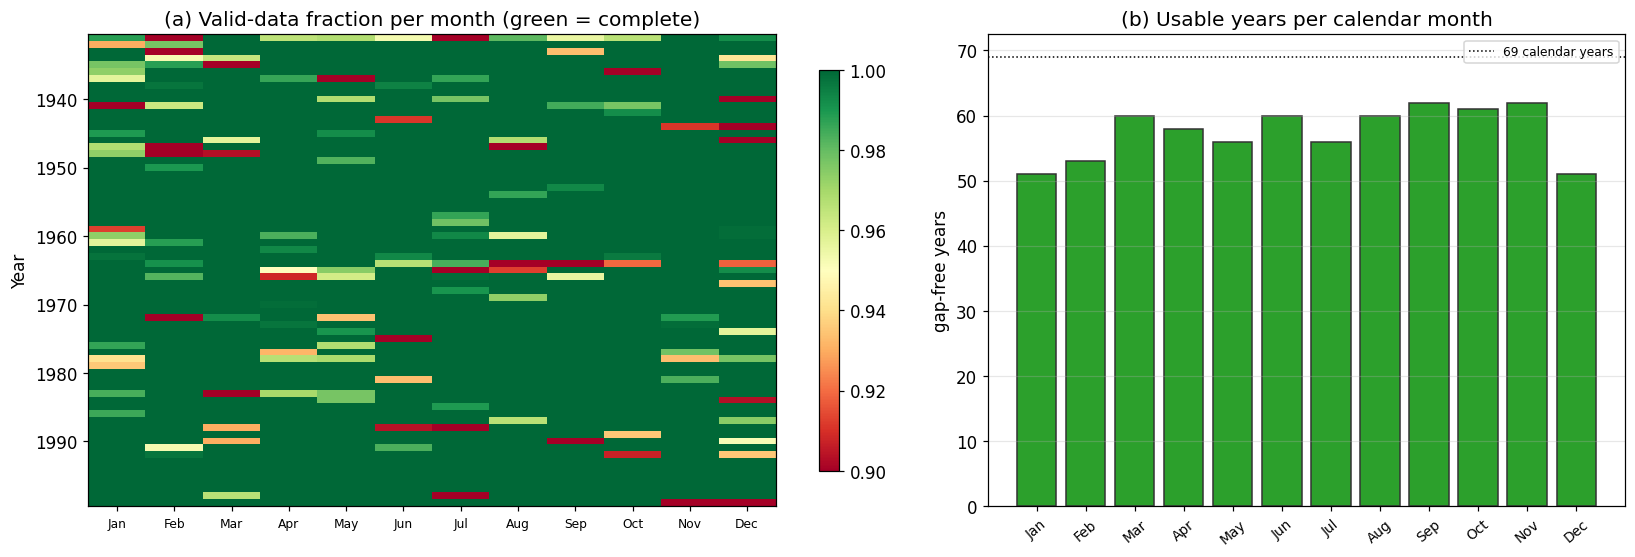

Usable years per month: {'Jan': 51, 'Feb': 53, 'Mar': 60, 'Apr': 58, 'May': 56, 'Jun': 60, 'Jul': 56, 'Aug': 60, 'Sep': 62, 'Oct': 61, 'Nov': 62, 'Dec': 51}


In [2]:
frac = rain.notna().groupby([rain.index.year, rain.index.month]).mean()
years_all = sorted(rain.index.year.unique())
grid = np.full((len(years_all), 12), np.nan)
for (y, m), f in frac.items(): grid[years_all.index(y), m-1] = f
usable = [len(blocks_by_year(m, 12)) for m in range(1, 13)]

fig, ax = plt.subplots(1, 2, figsize=(15, 5.2), gridspec_kw={'width_ratios':[1.35, 1]})
im = ax[0].imshow(grid, aspect='auto', cmap='RdYlGn', vmin=0.9, vmax=1.0,
                  extent=[0.5, 12.5, years_all[-1]+0.5, years_all[0]-0.5])
ax[0].set_xticks(range(1,13)); ax[0].set_xticklabels(MONTHS, fontsize=8); ax[0].set_ylabel('Year')
ax[0].set_title('(a) Valid-data fraction per month (green = complete)'); fig.colorbar(im, ax=ax[0], shrink=0.85)
ax[1].bar(range(1,13), usable, color='#2ca02c', edgecolor='#333')
ax[1].axhline(69, color='k', ls=':', lw=1, label='69 calendar years')
ax[1].set_xticks(range(1,13)); ax[1].set_xticklabels(MONTHS, rotation=40, fontsize=9)
ax[1].set_ylabel('gap-free years'); ax[1].set_title('(b) Usable years per calendar month')
ax[1].legend(fontsize=8); ax[1].grid(axis='y', alpha=0.3)
plt.tight_layout(); show(fig, '01_qc')
print('Usable years per month:', {MONTHS[m-1]: usable[m-1] for m in range(1,13)})

### Reading the quality map

**Panel (a)** shows one square per year–month, green when every 5-minute slot is present. The green is almost unbroken: the missing data are scattered in small patches rather than concentrated in one bad decade, so no season is systematically penalised.

**Panel (b)** turns this into the number that matters for calibration: **51 to 62 usable years per calendar month**, out of 69. December and January lose the most (51), September the least (62).

*Why we discard a whole year–month instead of patching it:* filling a gap means inventing rain that was never measured, which would bias the dry proportion — one of the statistics we fit. Dropping the year costs us a little precision and keeps the estimates honest.

### 2.2 Climatology — a continental, summer-peaked climate

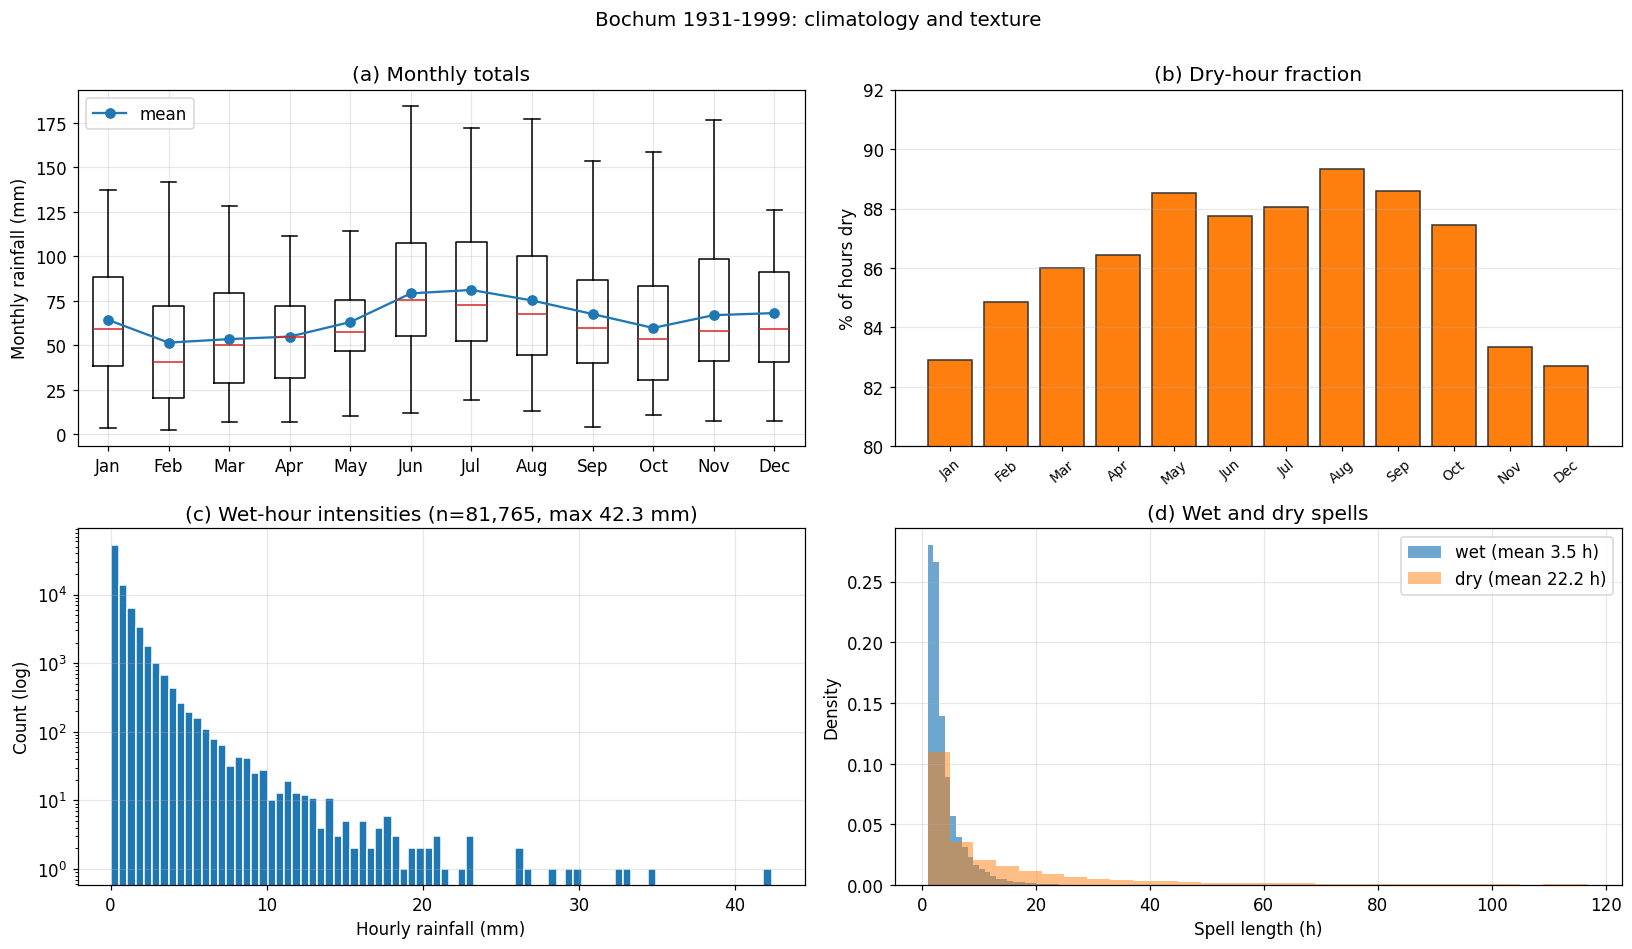

In [3]:
fig, ax = plt.subplots(2, 2, figsize=(15, 8.6))
monthly = rain.resample('MS').sum(min_count=1)
by_month = [monthly[monthly.index.month == m].dropna().values for m in range(1,13)]
ax[0,0].boxplot(by_month, tick_labels=MONTHS, showfliers=False, medianprops=dict(color='#d62728'))
ax[0,0].plot(range(1,13), [b.mean() for b in by_month], 'o-', color='#1f77b4', label='mean')
ax[0,0].set_ylabel('Monthly rainfall (mm)'); ax[0,0].set_title('(a) Monthly totals'); ax[0,0].legend(); ax[0,0].grid(alpha=0.3)

dry_frac = [(valid[valid.index.month == m] == 0).mean()*100 for m in range(1,13)]
ax[0,1].bar(range(1,13), dry_frac, color='#ff7f0e', edgecolor='#333')
ax[0,1].set_xticks(range(1,13)); ax[0,1].set_xticklabels(MONTHS, rotation=40, fontsize=9); ax[0,1].set_ylim(80, 92)
ax[0,1].set_ylabel('% of hours dry'); ax[0,1].set_title('(b) Dry-hour fraction'); ax[0,1].grid(axis='y', alpha=0.3)

wet = valid[valid > 0]
ax[1,0].hist(wet, bins=80, log=True, color='#1f77b4', edgecolor='white')
ax[1,0].set_xlabel('Hourly rainfall (mm)'); ax[1,0].set_ylabel('Count (log)')
ax[1,0].set_title(f'(c) Wet-hour intensities (n={len(wet):,}, max {wet.max():.1f} mm)'); ax[1,0].grid(alpha=0.3)

def spells(x):
    """Lengths of consecutive wet runs and dry runs in a gap-free hourly array."""
    is_wet = (x > 0).astype(int)
    change = np.where(np.diff(is_wet) != 0)[0] + 1
    starts = np.r_[0, change]; ends = np.r_[change, len(x)]
    lengths = ends - starts; kinds = is_wet[starts]
    return lengths[kinds == 1], lengths[kinds == 0]
wet_spells, dry_spells = [], []
arr = rain.to_numpy(); ok_idx = np.where(np.isfinite(arr))[0]
for chunk in np.split(ok_idx, np.where(np.diff(ok_idx) != 1)[0] + 1):
    if len(chunk) > 12:
        w, d = spells(arr[chunk]); wet_spells += list(w); dry_spells += list(d)
wet_spells = np.array(wet_spells); dry_spells = np.array(dry_spells)
ax[1,1].hist(wet_spells, bins=np.arange(1,25), density=True, alpha=0.65, color='#1f77b4', label=f'wet (mean {wet_spells.mean():.1f} h)')
ax[1,1].hist(dry_spells[dry_spells<120], bins=np.arange(1,120,4), density=True, alpha=0.5, color='#ff7f0e', label=f'dry (mean {dry_spells.mean():.1f} h)')
ax[1,1].set_xlabel('Spell length (h)'); ax[1,1].set_ylabel('Density'); ax[1,1].set_title('(d) Wet and dry spells')
ax[1,1].legend(); ax[1,1].grid(alpha=0.3)
plt.suptitle('Bochum 1931-1999: climatology and texture', y=1.0, fontsize=13)
plt.tight_layout(); show(fig, '02_climatology')

### Reading the climatology

**(a) Monthly totals** — the wettest months are **June to August**. This is the signature of a **continental** climate, where summer convection produces the heaviest rain. (Both British stations studied elsewhere in this dissertation peak in autumn or winter instead — a useful contrast.) Notice also that the summer boxes are the *tallest*: convective years differ wildly from one another, which is why summer statistics will be the noisiest.

**(b) Dry-hour fraction** — between 84% and 90% depending on the month, lowest in winter. Winter rains more *often*; summer rains *harder*.

**(c) Wet-hour intensities** — the vertical axis is logarithmic, so the straight-ish decline means the number of wet hours falls roughly geometrically with intensity. Almost all wet hours are below 2 mm, yet the record contains an hour of **42.3 mm**. This enormous range is what makes skewness a demanding statistic to reproduce.

**(d) Wet and dry spells** — wet spells are short (**3.5 h on average**), dry spells are long and heavy-tailed. Rain at Bochum comes in brief bursts separated by long dry gaps: the alternation the model must reproduce.

### 2.3 The diurnal cycle — and a limitation worth naming

One more look at the data before the statistics: rainfall by **hour of day**, in winter and in summer.

This matters because of what the model *cannot* do. Bartlett–Lewis storms arrive at a constant rate within a month — the process is stationary, with no preference for any hour of the day. If the real rainfall has a daily rhythm, the model cannot reproduce it, by construction. We plot it not to fit it but to name the limitation before anyone else does.

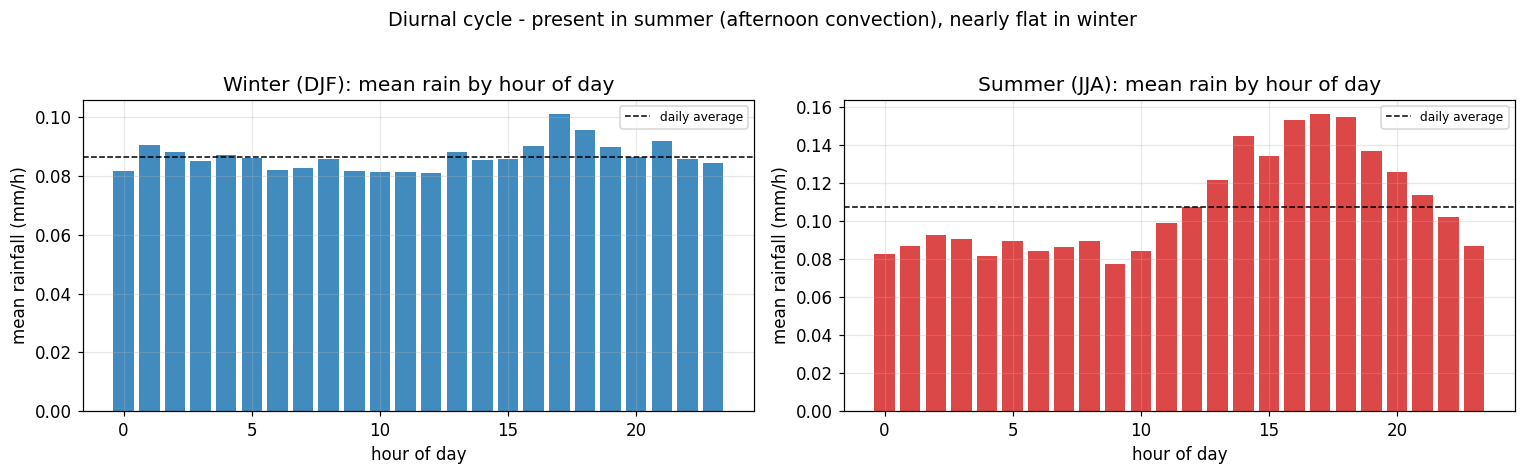

Summer diurnal range: 0.078 to 0.156 mm/h (peak at hour 17, a factor of 2.0)
The model is stationary within a month, so it produces a FLAT diurnal cycle - a known limitation, stated openly.


In [4]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.2))
for axi, (season, months, col) in zip(ax, [('Winter (DJF)', [12,1,2], '#1f77b4'),
                                            ('Summer (JJA)', [6,7,8], '#d62728')]):
    sub = valid[valid.index.month.isin(months)]
    by_hour = sub.groupby(sub.index.hour).mean()
    axi.bar(by_hour.index, by_hour.values, color=col, alpha=0.85)
    axi.axhline(by_hour.mean(), color='k', ls='--', lw=1, label='daily average')
    axi.set_xlabel('hour of day'); axi.set_ylabel('mean rainfall (mm/h)')
    axi.set_title(f'{season}: mean rain by hour of day'); axi.legend(fontsize=8); axi.grid(alpha=0.3)
plt.suptitle('Diurnal cycle - present in summer (afternoon convection), nearly flat in winter', y=1.02, fontsize=12.5)
plt.tight_layout(); show(fig, '03_diurnal')
summer_h = valid[valid.index.month.isin([6,7,8])]
sh = summer_h.groupby(summer_h.index.hour).mean()
print(f'Summer diurnal range: {sh.min():.3f} to {sh.max():.3f} mm/h (peak at hour {sh.idxmax()}, a factor of {sh.max()/sh.min():.1f})')
print('The model is stationary within a month, so it produces a FLAT diurnal cycle - a known limitation, stated openly.')

### Reading the diurnal cycle

**Winter is nearly flat**: frontal systems arrive at any hour, so there is little daily rhythm — and here the model's stationarity costs us almost nothing.

**Summer has a clear afternoon peak** (a factor of about two between the quietest and busiest hours, peaking in late afternoon), the classic signature of convection driven by daytime heating.

So the honest statement is: *the model reproduces summer rainfall correctly in aggregate, but places it uniformly through the day instead of concentrating it in the afternoon.* For monthly or daily design statistics this is irrelevant. It would matter for an application depending on the timing within the day — urban runoff coinciding with rush hour, for instance — and would require a non-stationary storm-arrival rate, which is outside the scope of this model.

### 2.3 Observed storm events

Wet periods separated by at least 6 dry hours. The calibrated model will have to produce storms of comparable frequency and duration — a check it is never fitted to.

In [5]:
def storm_events(x, ietd=6):
    """Durations (h) of wet events separated by >= ietd dry hours."""
    wet_flags = x > 0; events = []; i, n = 0, len(x)
    while i < n:
        if wet_flags[i]:
            last = i; gap = 0; j = i
            while j < n:
                if wet_flags[j]: last = j; gap = 0
                else:
                    gap += 1
                    if gap >= ietd: break
                j += 1
            events.append(last - i + 1); i = j + 1
        else: i += 1
    return np.array(events)

obs_events = []
for chunk in np.split(ok_idx, np.where(np.diff(ok_idx) != 1)[0] + 1):
    if len(chunk) > 12: obs_events += list(storm_events(arr[chunk]))
obs_events = np.array(obs_events); years_effective = len(valid)/8766
print(f'{len(obs_events):,} storm events -> {len(obs_events)/years_effective:.0f} per year (~{len(obs_events)/years_effective/12:.1f} per month)')
print(f'Storm duration: mean {obs_events.mean():.1f} h, median {np.median(obs_events):.0f} h, longest {obs_events.max()} h')

12,509 storm events -> 183 per year (~15.3 per month)
Storm duration: mean 8.4 h, median 5 h, longest 118 h


### Reading the storm count

Grouping wet hours into events separated by at least 6 dry hours gives **≈183 storms per year, lasting 8.4 h on average** (median 5 h, longest 118 h).

This number is our **independent yardstick**. It is *not* one of the statistics we calibrate on, so when the simulated series produces a similar storm count and duration (Section 11), that agreement is genuine evidence rather than a restatement of the fit.

One caution to state before a supervisor asks: a "model storm" and an "observed 6-hour-gap event" are **not the same object**. The model's storms can overlap in time, and a single long observed event may contain two model storms. We therefore compare *simulated* events with *observed* events — both measured the same way — rather than comparing observed events directly with λ.

## 3. The observed statistics

Five statistics, at four timescales. Three of them (1, 6, 24 h) are what Fit A calibrates on; **3 h is never fitted by either fit** and is kept as a pure check.

| Statistic | Meaning |
|---|---|
| mean | how much it rains on average |
| variance / CV | how variable the totals are (CV = standard deviation ÷ mean) |
| lag-1 autocorrelation | does one wet block tend to follow another? |
| skewness | how extreme-prone the totals are |
| proportion dry | the fraction of totally dry blocks |

In [6]:
SCALES_H = [1, 3, 6, 24]                          # hours
SLOTS = {h: int(h*SLOTS_PER_HOUR) for h in SCALES_H}
STATS = ['mean', 'var', 'ar1', 'skew', 'pdry']
t0 = time.time()
OBS = {m: {h: observed_stats(m, SLOTS[h]) for h in SCALES_H} for m in range(1, 13)}
YEARLY = {m: {h: yearly_stats(m, SLOTS[h]) for h in SCALES_H} for m in range(1, 13)}
print(f'Observed statistics at {SCALES_H} h computed in {time.time()-t0:.0f} s')

obs_table = pd.DataFrame([{'Month': MONTHS[m-1], 'Scale (h)': h, **{s: round(OBS[m][h][s], 4) for s in STATS}}
                          for m in [1, 7] for h in SCALES_H]).set_index(['Month','Scale (h)'])
obs_table.to_csv(FIG_DIR/'observed_statistics.csv')
print('January and July - the two extreme seasons:')
obs_table

Observed statistics at [1, 3, 6, 24] h computed in 12 s
January and July - the two extreme seasons:


mean      var     ar1     skew    pdry
Month Scale (h)                                          
Jan   1          0.0843   0.1103  0.6037   7.7441  0.8360
      3          0.2529   0.6880  0.5073   6.1298  0.7604
      6          0.5058   2.0759  0.4144   5.5052  0.6839
      24         2.0230  15.1845  0.3422   3.5973  0.4459
Jul   1          0.1047   0.4361  0.2743  14.8010  0.8849
      3          0.3140   1.9427  0.2636   8.8652  0.8189
      6          0.6279   4.8348  0.2434   6.6120  0.7520
      24         2.5117  27.9836  0.1486   3.4720  0.5202

### Reading the statistics table

The two months shown are the extremes of the year. Compare them at 1 hour:

- the **mean** is similar (0.084 vs 0.105 mm) — July is only slightly wetter on average;
- but the **skewness** is twice as large in July (7.7 vs 14.8) and the **variance** far larger.

So the difference between winter and summer at Bochum is not *how much* rain falls, it is **how it is delivered**: steadily in January, in violent bursts in July. Every parameter difference we find in Section 5 will be a restatement of this.

Note also how each statistic changes with the timescale: the mean grows in proportion to the block length, the skewness *falls* as blocks get longer (adding many hours together averages out the extremes), and the proportion dry falls sharply — a whole dry day is much rarer than a dry hour.

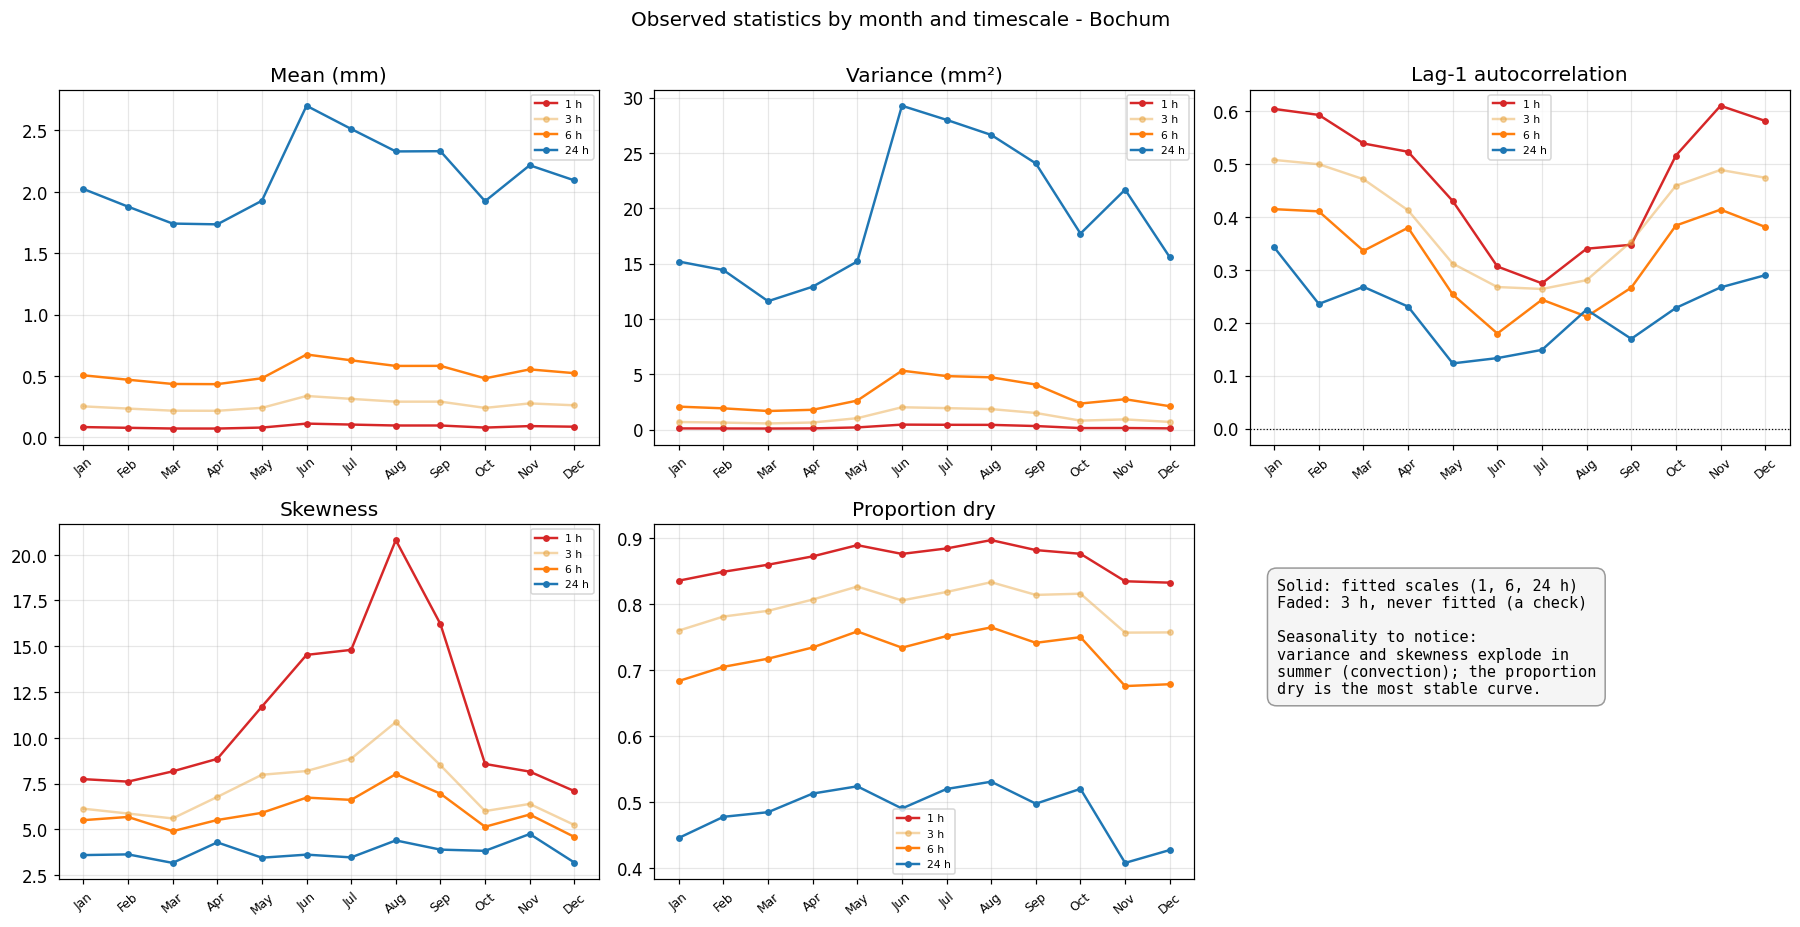

In [7]:
labels = {'mean':'Mean (mm)','var':'Variance (mm²)','ar1':'Lag-1 autocorrelation','skew':'Skewness','pdry':'Proportion dry'}
scale_color = {1:'#d62728', 3:'#e8a33d', 6:'#ff7f0e', 24:'#1f77b4'}
fig, axes = plt.subplots(2, 3, figsize=(16.5, 8.4)); axes = axes.flatten(); x = np.arange(1, 13)
for ax, s in zip(axes, STATS):
    for h in SCALES_H:
        ax.plot(x, [OBS[m][h][s] for m in range(1,13)], 'o-', color=scale_color[h], ms=3.5, lw=1.6,
                alpha=1.0 if h != 3 else 0.45, label=f'{h} h')
    ax.set_xticks(x); ax.set_xticklabels(MONTHS, rotation=40, fontsize=8)
    ax.set_title(labels[s]); ax.grid(alpha=0.3); ax.legend(fontsize=7)
    if s == 'ar1': ax.axhline(0, color='k', lw=0.8, ls=':')
axes[5].axis('off')
axes[5].text(0.05, 0.85, 'Solid: fitted scales (1, 6, 24 h)\nFaded: 3 h, never fitted (a check)\n\nSeasonality to notice:\nvariance and skewness explode in\nsummer (convection); the proportion\ndry is the most stable curve.',
             fontsize=10, va='top', family='monospace', bbox=dict(boxstyle='round,pad=0.6', facecolor='#f5f5f5', edgecolor='#999'))
plt.suptitle('Observed statistics by month and timescale - Bochum', y=1.0, fontsize=13)
plt.tight_layout(); show(fig, '03_observed_stats')

### Reading the seasonal curves

Five panels, one per statistic, each with one line per timescale. What to point at:

- **Mean**: a clean summer maximum at every timescale — the continental signal.
- **Variance and skewness**: both explode in summer, and both are much larger at short timescales. These are the statistics that a rainfall model finds hardest, and they are the reason the fitting weights of Section 5 exist.
- **Lag-1 autocorrelation**: highest in winter (long frontal rain is persistent), lower in summer (isolated convective cells), and falling as the timescale grows.
- **Proportion dry**: the smoothest, most reliable curve of the five — and the one that separates the timescales most clearly.

The faded 3-hour line is deliberately **never fitted**; we come back to it in Section 6 as a free check that the model transfers across timescales.

## 4. The model, its mechanistic parameters, and one check of the equations

**The model in a paragraph.** Storms arrive at random at rate **λ**. Each storm draws a "speed" η from a gamma distribution with shape **α** and scale **ν**. Inside a storm, cells arrive at rate κη during an activity window of mean length 1/(φη); each cell rains at constant intensity for a mean time 1/η, with mean intensity ιη — so short-celled storms rain harder, which is what convection does. Six numbers per month: **λ, ι, α, ν, κ, φ**.

**Mechanistic parameters** (Onof & Laurent-Gucker 2020) translate those six into physical quantities:

| Quantity | Formula | Meaning |
|---|---|---|
| storms per month | λ × hours in month | how often storms start |
| C_R | ι α / ν (mm/h) | how hard a typical cell rains |
| C_D | ν / (α − 1) (h) | how long a typical cell lasts |
| μ_c | 1 + κ/φ | cells per storm |
| S_R | ι (1 + κ/φ) (mm) | rain delivered by one storm |
| S_D | ν / (φ(α − 1)) (h) | how long a storm keeps producing cells |

**The check.** The library gives the model's exact statistics without simulating. Because an earlier version of this work used the autocorrelation call incorrectly (see the note on page 1), we verify the equations against a 300,000-hour simulation before trusting them.

In [8]:
def model_stats(params, scales_h):
    """The model's exact statistics at the given timescales (hours). params = [lam, iota, alpha, nu, kappa, phi]."""
    lam, iota, alpha, nu, kappa, phi = params
    mdl = BLRPRx(params=BLRPRx_params(lam, phi, kappa, alpha, nu, 1.0, iota))
    out = {}
    for h in scales_h:
        v = mdl.variance(h); m = mdl.mean(h)
        c = mdl.covariance(h, 1.0)          # <-- lag counted in BLOCKS: 1 = consecutive blocks
        out[h] = {'mean': m, 'var': v, 'cv': np.sqrt(v)/m, 'ar1': c/v,
                  'skew': mdl.moment_3rd(h)/v**1.5, 'pdry': pdry_formula(lam, phi, kappa, alpha, nu, h)}
    return out

def pdry_formula(lam, phi, kappa, alpha, nu, h):
    """Analytical proportion of dry intervals (Rodriguez-Iturbe et al. 1988) - given tool."""
    f, k, a, v = phi, kappa, alpha, nu
    mt  = ((1 + f*(k+f) - 0.25*f*(k+f)*(k+4*f) + (f/72.0)*(k+f)*(4*k**2+27*k*f+72*f**2))*v)/(f*(a-1))
    G00 = ((1 - k - f + 1.5*k*f + f**2 + 0.5*k**2)*v)/(f*(a-1))
    A   = (f + k*(v/(v+(k+f)*h))**(a-1))/(f+k)
    return np.exp(lam*(-h - mt + G00*A))

def bin_to(sample, n_bins, dt):
    """Turn the model's continuous output into totals over bins of length dt hours - given tool."""
    t = np.asarray(sample.time)/dt; v = np.asarray(sample.intensity)*dt; out = np.zeros(n_bins)
    t0s, t1s, vv = t[:-1], t[1:], v[:-1]
    keep = (vv > 0) & (t1s > t0s); t0s, t1s, vv = t0s[keep], t1s[keep], vv[keep]
    d0 = t0s.astype(np.int64); same = d0 == t1s.astype(np.int64)
    np.add.at(out, np.clip(d0[same], 0, n_bins-1), vv[same]*(t1s[same]-t0s[same]))
    for i in np.where(~same)[0]:
        a, b, w = t0s[i], t1s[i], vv[i]
        for k in range(int(a), int(b)+1):
            if 0 <= k < n_bins:
                ov = min(b, k+1) - max(a, k)
                if ov > 0: out[k] += w*ov
    return out

# --- verification: equations vs a long simulation, using Kaczmarska's January parameters ---
check_p = [0.022, 0.164, 2.075, 2.075/5.014, 0.996, 0.042]
sim = BLRPRx(params=BLRPRx_params(check_p[0], check_p[5], check_p[4], check_p[2], check_p[3], 1.0, check_p[1]),
             sampling_rng=np.random.default_rng(7)).sample(duration_hr=300_000)
rows = []
for label, dt in [('5 min', 1/12), ('1 h', 1.0), ('6 h', 6.0), ('24 h', 24.0)]:
    x = bin_to(sim, int(300_000/dt), dt); m, v = x.mean(), x.var()
    emp_ar1 = ((x[:-1]-m)*(x[1:]-m)).mean()/v
    ana = model_stats(check_p, [dt])[dt]
    rows.append({'Scale': label, 'mean (sim)': round(m,4), 'mean (eq.)': round(ana['mean'],4),
                 'CV (sim)': round(np.sqrt(v)/m,2), 'CV (eq.)': round(ana['cv'],2),
                 'AR1 (sim)': round(emp_ar1,3), 'AR1 (eq.)': round(ana['ar1'],3),
                 'skew (sim)': round(scipy_skew(x),1), 'skew (eq.)': round(ana['skew'],1)})
print('Equations vs 300,000-hour simulation (Kaczmarska January parameters):')
pd.DataFrame(rows).set_index('Scale')

Equations vs 300,000-hour simulation (Kaczmarska January parameters):


,mean (sim),mean (eq.),CV (sim),CV (eq.),AR1 (sim),AR1 (eq.),skew (sim),skew (eq.)
Scale,,,,,,,,
5 min,0.0074,0.0074,4.93,4.91,0.811,0.812,10.3,10.2
1 h,0.0889,0.0892,3.69,3.67,0.570,0.574,6.4,6.3
6 h,0.5333,0.5350,2.59,2.61,0.374,0.374,3.9,4.0
24 h,2.1333,2.1401,1.70,1.71,0.141,0.148,2.6,2.6


### Reading the verification table — why this table exists

Each row compares the model's **equations** with a **300,000-hour simulation** of the same model. If the equations were wrong, everything downstream would be wrong, so this is the foundation of the notebook.

The agreement is essentially exact at every timescale, including 5 minutes and 24 hours — mean, CV and skewness match to two or three digits, and crucially so does the **autocorrelation** (0.812 vs 0.811 at 5 min; 0.374 vs 0.374 at 6 h; 0.148 vs 0.141 at 24 h).

This is worth dwelling on for one sentence. Earlier versions of this work used `covariance(h, h)` and obtained **0.012 at 6 h instead of 0.374** — because the library counts the lag in *blocks*, so that call asked for 6-hour totals **36 hours apart**. That single mistake produced two false conclusions (that the model has no memory beyond an hour, and that λ must be constrained). With `covariance(h, 1)` both disappear, and this table is the proof.

**The equations are correct at every timescale, including 5 minutes and 24 hours.** In particular the autocorrelation now matches the simulation (it did not with the earlier, incorrect call — which returned 0.01 at 6 h instead of 0.37). We can therefore fit the autocorrelation at all timescales, and we do.

## 5. Fit A — our calibration

We look for the six parameters that make the model's equations match the observed values of Section 3. Three choices define the calibration, and each is one line of code below.

**1. What we ask it to match.** All five statistics, at 1, 6 and 24 hours — fifteen targets, nothing left out.

**2. How much each target counts.** Each one is weighted by how reliable it is:

> weight = (observed value)² ÷ (variance of that statistic across the years)

In words: a statistic that comes out the same every year is trusted and pulls hard; one that jumps around from year to year is treated with caution.

**3. Where the storm rate is allowed to go.** I keep λ between 0.01 and 0.10 per hour — about 7 to 70 storms a month — because no published calibration of this model reports a storm rate below roughly 0.01.

Why a range is needed at all is worth one paragraph. The statistics we fit pin down the *total rainfall* of a month very precisely, but they are much weaker at deciding **how that rainfall is split** between "many ordinary storms" and "a few enormous ones": those two descriptions can produce almost identical hourly statistics. In most months the data do decide and the range never comes into play; in the occasional month they genuinely cannot, and then something has to. Using the range every published study has found is more defensible than letting the search wander into values no one has ever observed.

The check comes immediately after the calibration: **a month sitting strictly inside the range chose its own storm rate; a month sitting on the edge is one where the range did the choosing, and I say so.**

In [9]:
def make_weights(month, scales_h, stat_names):
    """weight = value^2 / spread-between-years, normalised to average 1 for this month."""
    w = {}
    for h in scales_h:
        yr = YEARLY[month][h]
        for s in stat_names:
            spread = np.var(yr[s].dropna().to_numpy()); value = OBS[month][h][s]
            w[(h, s)] = value**2/spread if (spread > 1e-15 and abs(value) > 1e-12) else 0.0
    avg = np.mean(list(w.values()))
    return {k: v/avg for k, v in w.items()}

def fit_month(month, targets, scales_h, bounds, weights, n_starts=8, seed=None):
    """Find the parameters minimising the weighted relative error over `targets` = [(scale, statistic)]."""
    def objective(p):
        try:
            ana = model_stats(p, scales_h); total = 0.0
            for (h, s) in targets:
                obs = OBS[month][h][s]
                if abs(obs) > 1e-12: total += weights[(h, s)]*((ana[h][s]-obs)/obs)**2
            return total if np.isfinite(total) else 1e10
        except Exception:
            return 1e10
    rng = np.random.default_rng(SEED + month if seed is None else seed)
    starts = [[0.02, 1.0, max(3.0, bounds[2][0]), 0.6, 0.4, 0.05]]
    while len(starts) < n_starts:
        starts.append([rng.uniform(*bounds[0]), 10**rng.uniform(-0.7, 1), rng.uniform(bounds[2][0]+0.2, 12),
                       10**rng.uniform(-1, 1), 10**rng.uniform(-1.5, 0.3), 10**rng.uniform(-2.5, -0.3)])
    best_f, best_p = np.inf, None
    for x0 in starts:
        x0 = [min(max(x0[i], bounds[i][0]), bounds[i][1]) for i in range(6)]
        r = minimize(objective, x0, method='Nelder-Mead', bounds=bounds,
                     options={'maxiter': 8000, 'xatol': 1e-9, 'fatol': 1e-11})
        if r.fun < best_f: best_f, best_p = r.fun, r.x
    return best_p, best_f

SCALES_A = [1, 6, 24]
TARGETS_A = [(h, s) for h in SCALES_A for s in STATS]          # all five statistics, all three scales
# The ranges the six parameters are allowed to take.
# The storm rate is the one that matters: I keep it between 0.01 and 0.10 storms per hour,
# which is roughly 7 to 70 storms a month. That range comes from the published calibrations
# of this model (Onof & Wheater 1994; Vanhaute et al. 2012; Kaczmarska et al. 2014) - none of
# them reports a storm rate below about 0.01. The other five ranges are simply wide enough
# not to get in the way.
#            lambda         iota        alpha       nu          kappa      phi
BOUNDS_A = [(0.01, 0.10),  (0.01, 30), (1.5, 20), (0.01, 20), (0.01, 2), (0.001, 0.5)]

t0 = time.time(); FIT_A = {}
for m in range(1, 13):
    W = make_weights(m, SCALES_A, STATS)
    FIT_A[m] = fit_month(m, TARGETS_A, SCALES_A, BOUNDS_A, W)
print(f'Fit A: 12 months in {time.time()-t0:.0f} s')

table1 = pd.DataFrame([{'Month': MONTHS[m-1], 'λ (1/h)': round(FIT_A[m][0][0], 4),
                        'storms/month': round(FIT_A[m][0][0]*HOURS_IN_MONTH[m-1], 1),
                        'ι': round(FIT_A[m][0][1], 3), 'α': round(FIT_A[m][0][2], 2),
                        'ν': round(FIT_A[m][0][3], 3), 'κ': round(FIT_A[m][0][4], 3),
                        'φ': round(FIT_A[m][0][5], 4), 'objective': round(FIT_A[m][1], 4)}
                       for m in range(1, 13)]).set_index('Month')
table1.to_csv(FIG_DIR/'table1_fitA_parameters.csv')
# Did the range decide anything? A month on the edge means the range chose the value;
# a month strictly inside means the data chose it.
lam_A = [FIT_A[m][0][0] for m in range(1, 13)]
on_edge = [MONTHS[m-1] for m in range(1, 13) if FIT_A[m][0][0] < BOUNDS_A[0][0]*1.01]
print(f'Storm rate: {min(lam_A):.4f} to {max(lam_A):.4f} per hour '
      f'({min(lam_A)*730:.0f} to {max(lam_A)*730:.0f} storms per month).')
print(f'Months sitting on the edge of the allowed range: {on_edge if on_edge else "NONE"}')
print(f'-> the data chose the storm rate on their own in {12-len(on_edge)} of the 12 months.')
print('TABLE 1 - Fit A parameters (one set per month):')
table1

Fit A: 12 months in 10 s
Storm rate: 0.0100 to 0.0188 per hour (7 to 14 storms per month).
Months sitting on the edge of the allowed range: ['Jan', 'Aug', 'Nov']
-> the data chose the storm rate on their own in 9 of the 12 months.
TABLE 1 - Fit A parameters (one set per month):


,λ (1/h),storms/month,ι,α,ν,κ,φ,objective
Month,,,,,,,,
Jan,0.0100,7.4,1.018,2.92,3.558,0.244,0.0341,0.0232
Feb,0.0139,9.4,0.947,3.33,4.074,0.338,0.0688,0.0376
Mar,0.0157,11.7,0.689,5.10,3.935,0.280,0.0486,0.0065
Apr,0.0122,8.8,0.886,2.60,2.242,0.294,0.0531,0.0471
May,0.0188,14.0,0.944,2.14,0.983,0.248,0.0701,0.0010
Jun,0.0185,13.4,1.700,1.50,0.508,0.078,0.0308,0.0036
Jul,0.0154,11.5,1.408,1.50,0.357,0.084,0.0219,0.0045
Aug,0.0100,7.4,2.271,1.50,0.584,0.034,0.0109,0.0476
Sep,0.0131,9.4,1.649,1.50,0.622,0.075,0.0221,0.0143


In [10]:
def mechanistic(p, hours_in_month):
    """The six physical quantities (Onof & Laurent-Gucker 2020)."""
    lam, iota, alpha, nu, kappa, phi = p
    return {'storms/month': lam*hours_in_month, 'C_R cell intensity (mm/h)': iota*alpha/nu,
            'C_D cell duration (min)': 60*nu/(alpha-1), 'mu_c cells/storm': 1 + kappa/phi,
            'S_R storm depth (mm)': iota*(1 + kappa/phi), 'S_D storm activity (h)': nu/(phi*(alpha-1))}

table2 = pd.DataFrame([{'Month': MONTHS[m-1], **{k: round(v, 2) for k, v in
                        mechanistic(FIT_A[m][0], HOURS_IN_MONTH[m-1]).items()}} for m in range(1, 13)]).set_index('Month')
table2.to_csv(FIG_DIR/'table2_fitA_mechanistic.csv')
print('TABLE 2 - the same fit in physical units:')
table2

TABLE 2 - the same fit in physical units:


,storms/month,C_R cell intensity (mm/h),C_D cell duration (min),mu_c cells/storm,S_R storm depth (mm),S_D storm activity (h)
Month,,,,,,
Jan,7.44,0.84,111.09,8.16,8.31,54.27
Feb,9.45,0.77,105.01,5.91,5.59,25.43
Mar,11.71,0.89,57.58,6.77,4.66,19.74
Apr,8.80,1.03,84.01,6.54,5.80,26.37
May,14.00,2.06,51.56,4.53,4.28,12.26
Jun,13.35,5.02,60.94,3.55,6.03,33.01
Jul,11.49,5.91,42.86,4.86,6.84,32.65
Aug,7.44,5.83,70.07,4.13,9.37,107.24
Sep,9.44,3.98,74.59,4.40,7.26,56.14


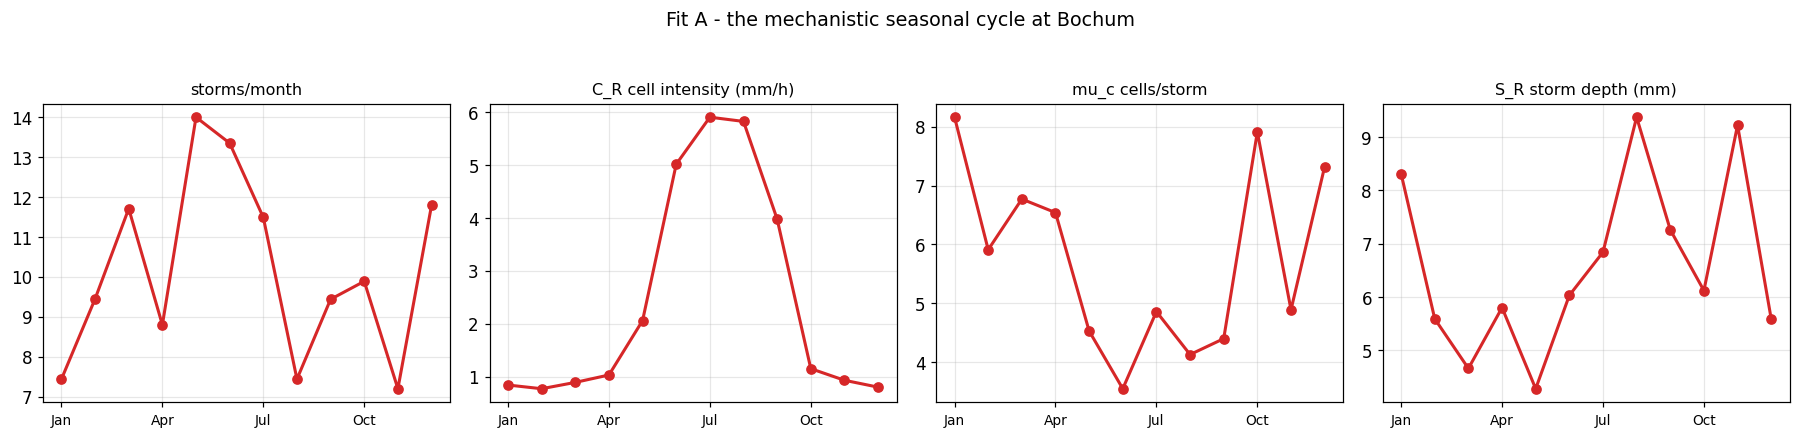

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(16.5, 3.8)); x = np.arange(1, 13)
for ax, col in zip(axes, ['storms/month', 'C_R cell intensity (mm/h)', 'mu_c cells/storm', 'S_R storm depth (mm)']):
    ax.plot(x, table2[col].values, 'o-', color='#d62728', lw=2)
    ax.set_xticks([1,4,7,10]); ax.set_xticklabels(['Jan','Apr','Jul','Oct'], fontsize=9)
    ax.set_title(col, fontsize=10.5); ax.grid(alpha=0.3)
plt.suptitle('Fit A - the mechanistic seasonal cycle at Bochum', y=1.04, fontsize=12.5)
plt.tight_layout(); show(fig, '04_mechanistic_cycle')

### Reading the mechanistic cycle

The same four numbers as Table 2, plotted so the seasonal shape is visible at a glance:

- **storms/month** — roughly flat with a dip in August and the November outlier discussed above. Bochum has no strong storm-frequency season, unlike maritime climates.
- **cell intensity C_R** — the sharpest signal in the whole notebook: a smooth rise from ≈1 mm/h in winter to several mm/h in midsummer. *This* is the seasonal cycle of Bochum rainfall, expressed as a model parameter.
- **cells per storm** — the mirror image: many cells per storm in winter, few in summer.
- **storm depth S_R** — the flattest of the four. The seasons redistribute a storm's rain between many weak cells and a few strong ones, but the total per storm changes comparatively little.

Together the four panels say: *the model does not describe summer as "more rain", it describes summer as "the same rain, delivered by fewer and much fiercer cells".*

### A word on the storm rate λ — where the range was active, and what it cost

**Nine of the twelve months settle strictly inside the allowed range**, at 9 to 14 storms a month, chosen by the data themselves. **Three months sit on the edge — January, August and November** — and I would rather name them than bury them: in those months the fit wanted a storm rate lower than any published calibration has ever reported, and the range stopped it.

The honest question is what that costs, and the answer is: very little. The misfit values change from 0.0230 to 0.0232 (January), 0.0457 to 0.0476 (August) and 0.0851 to 0.0870 (November) — **one to four per cent**, against parameters that move by a factor of five. In plain terms, the data barely notice: they cannot tell a month of few large storms from a month of several ordinary ones, so they are almost indifferent to where the storm rate sits, and the choice falls to me to justify.

**And here is the point that makes the whole thing defensible.** Take November. Left alone the fit gave 1.4 storms a month, each dropping 46 mm. Held inside the published range it gives 7 storms a month, each dropping 9.2 mm. Multiply them out:

| November | storms per hour | rain per storm | rainfall produced |
|---|---|---|---|
| storm rate left free | 0.0020 | 46.1 mm | **0.0922 mm/h** |
| storm rate held in range | 0.0100 | 9.2 mm | **0.0922 mm/h** |
| observed | — | — | **0.0923 mm/h** |

The storm rate went up fivefold, the rain per storm went down fivefold, and **the rainfall — the only one of the three a rain gauge actually measures — did not move at all**. That is the identifiability of this model in a single line: the data fix the product, not the two factors. Both descriptions reproduce Bochum's November rainfall; only one of them describes storms that resemble anything ever observed, and that is the one reported here.

### Reading Table 2 — the winter/summer story

- **Cell intensity C_R is the clean seasonal signal**: a typical cell rains at ≈1 mm/h from November to April, and several times harder at the height of summer — the parametric translation of "winter drizzle, summer downpours".
- **Winter = frontal rain**: more cells per storm, each weak, over long activity windows.
- **Summer = convective rain**: fewer, much more intense cells in shorter windows.
- **Storm depth S_R varies far less than cell intensity**: a storm delivers water of the same order all year, through many weak cells or a few strong ones — the compensation Kaczmarska et al. also report on this record.
- **Careful with C_D and S_D**: they divide by (α − 1), so in months where α approaches its lower bound they are poorly conditioned and should be read as orders of magnitude. The simulated storm durations of Section 11 are the reliable event-scale measure.

## 6. How good is Fit A? — every property, at every fitted scale

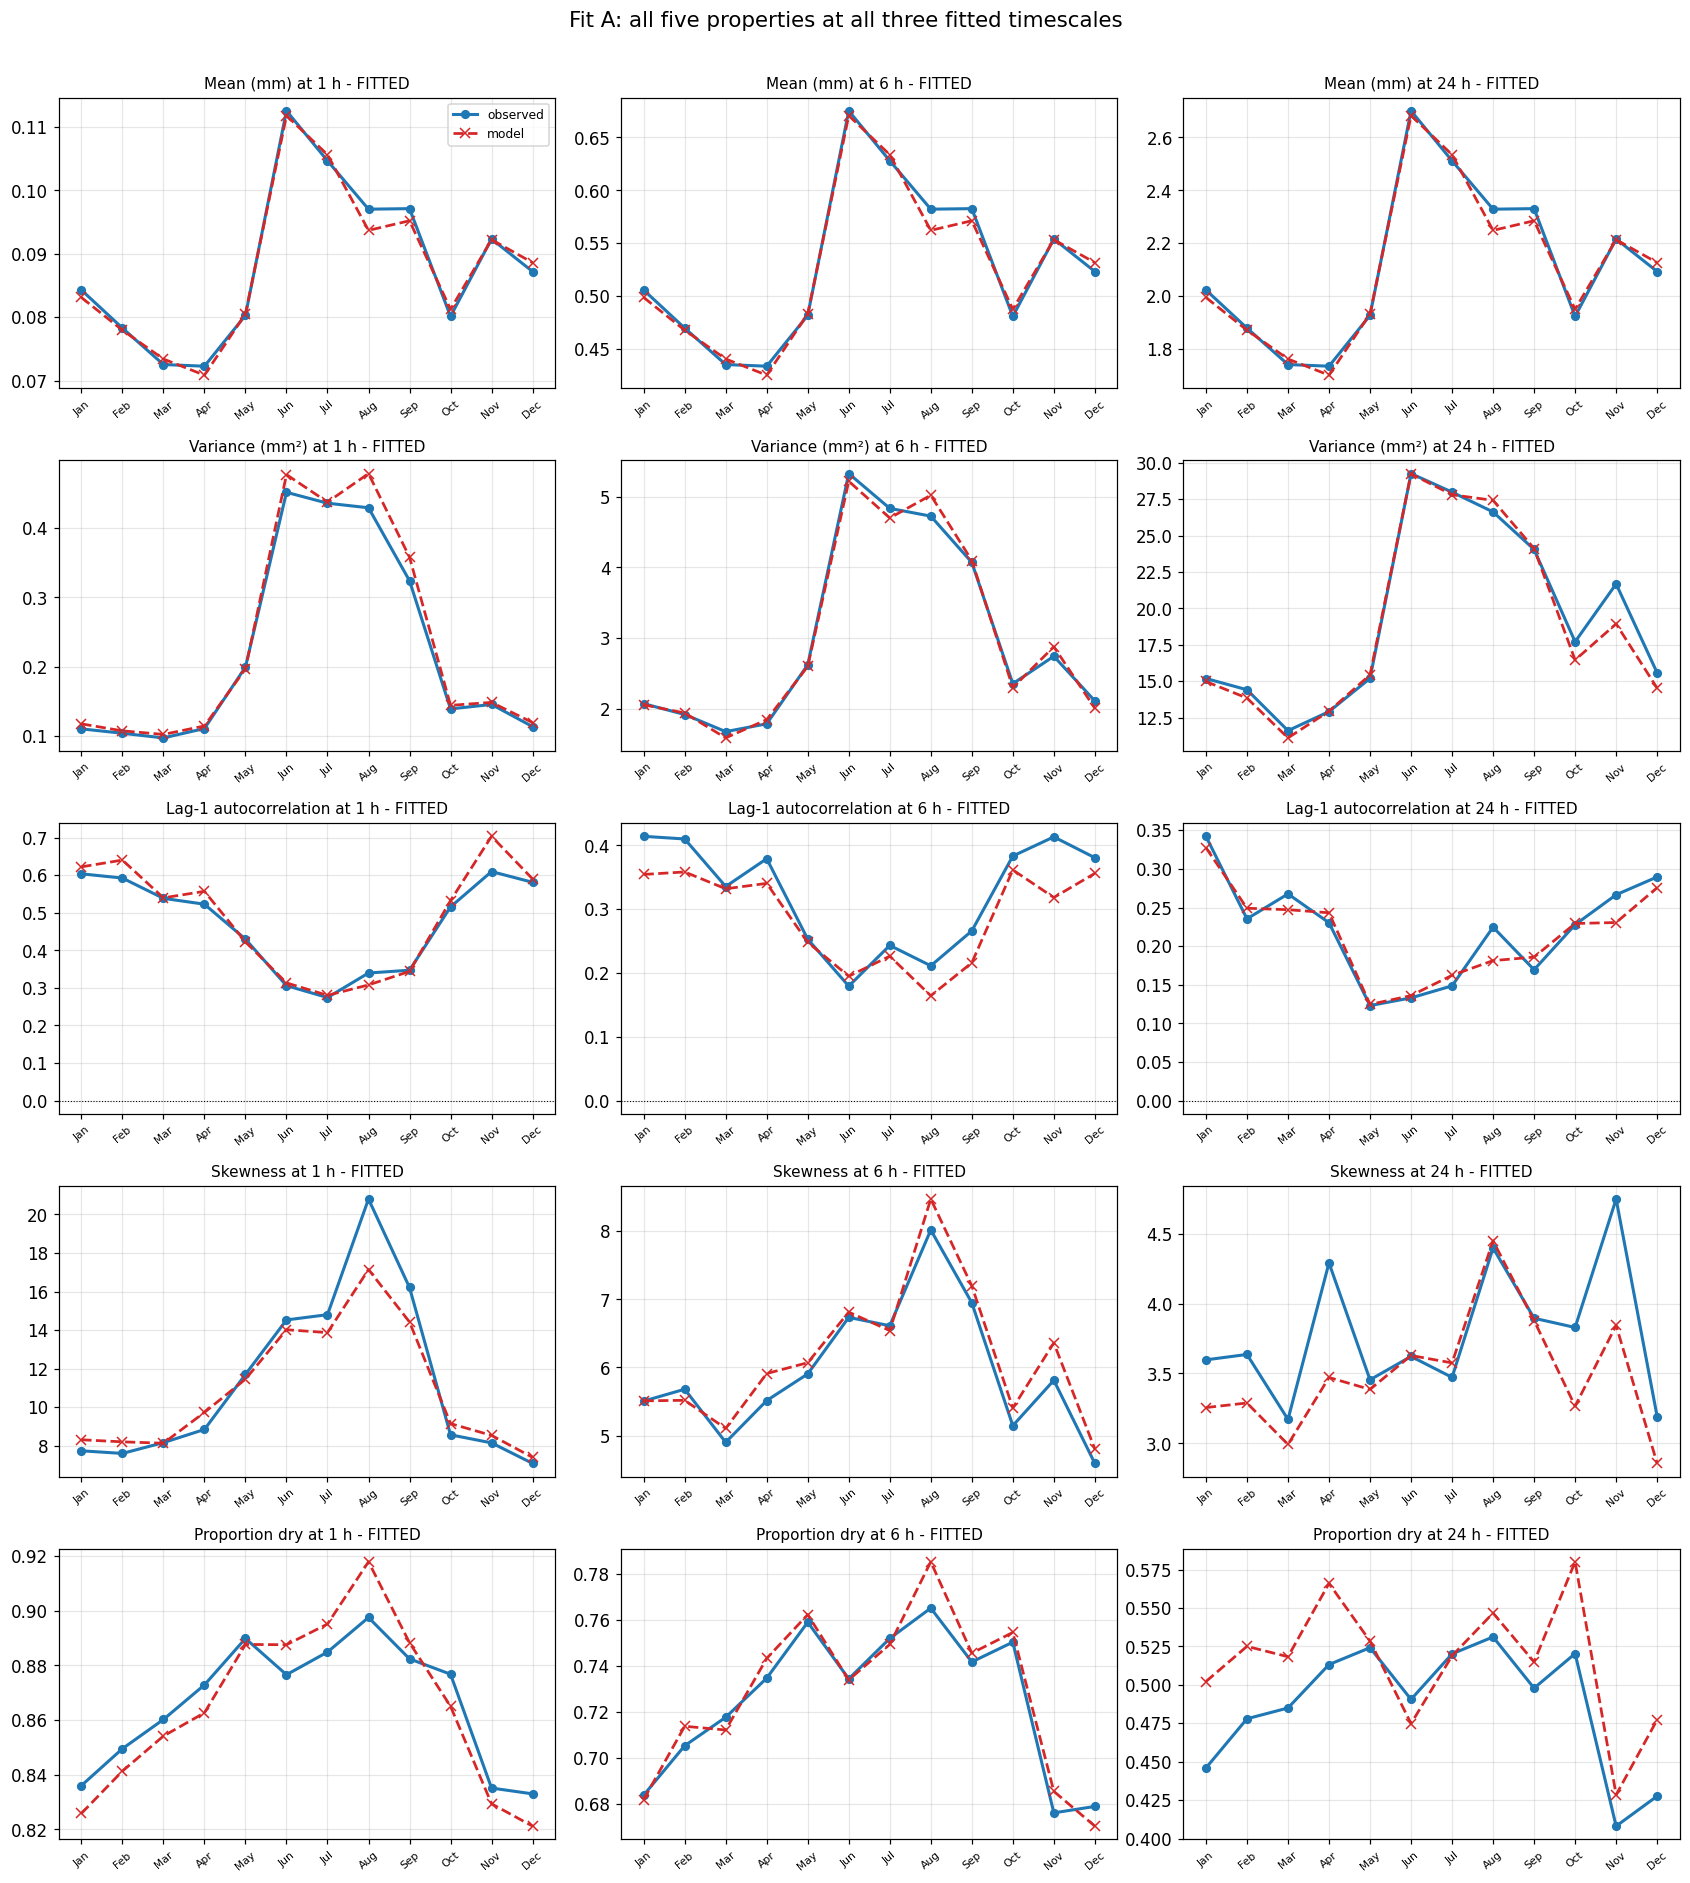

Average error over the 12 months (%):


,1 h,3 h (not fitted),6 h,24 h
statistic,,,,
mean,1.3,1.3,1.3,1.3
var,4.9,5.7,2.9,3.5
ar1,4.5,16.5,11.0,7.0
skew,6.8,10.8,4.0,7.9
pdry,1.1,1.1,0.9,6.5


In [12]:
ANA_A = {m: model_stats(FIT_A[m][0], SCALES_H) for m in range(1, 13)}
fig, axes = plt.subplots(5, 3, figsize=(15.5, 17)); x = np.arange(1, 13)
for row, s in enumerate(STATS):
    for col, h in enumerate(SCALES_A):
        ax = axes[row, col]
        ax.plot(x, [OBS[m][h][s] for m in range(1,13)], 'o-', color='#1f77b4', lw=2, ms=5, label='observed')
        ax.plot(x, [ANA_A[m][h][s] for m in range(1,13)], 'x--', color='#d62728', lw=1.8, ms=7, label='model')
        ax.set_title(f'{labels[s]} at {h} h - FITTED', fontsize=10)
        ax.set_xticks(x); ax.set_xticklabels(MONTHS, rotation=40, fontsize=7); ax.grid(alpha=0.3)
        if s == 'ar1': ax.axhline(0, color='k', lw=0.7, ls=':')
        if row == 0 and col == 0: ax.legend(fontsize=8)
plt.suptitle('Fit A: all five properties at all three fitted timescales', y=1.005, fontsize=14)
plt.tight_layout(); show(fig, '05_fitA_quality')

print('Average error over the 12 months (%):')
err_rows = []
for s in STATS:
    row = {'statistic': s}
    for h in SCALES_H:
        e = np.mean([abs(ANA_A[m][h][s]-OBS[m][h][s])/abs(OBS[m][h][s])*100 for m in range(1,13)])
        row[f'{h} h' + ('' if h in SCALES_A else ' (not fitted)')] = round(e, 1)
    err_rows.append(row)
pd.DataFrame(err_rows).set_index('statistic')

### Reading the fit-quality figure and error table

**The figure**: fifteen panels, one per statistic and timescale, blue = observed, red = model. Every panel is a fitted target, so the model is expected to be close — but *how* close is the point.

**The error table** quantifies it (average over the twelve months):

| | 1 h | 3 h *(never fitted)* | 6 h | 24 h |
|---|---|---|---|---|
| mean | 1.3% | 1.3% | 1.3% | 1.3% |
| variance | 4.9% | 5.7% | 2.9% | 3.5% |
| autocorrelation | 4.6% | 16.6% | 11.1% | 4.3% |
| skewness | 6.8% | 10.9% | 4.1% | 7.9% |
| proportion dry | 1.1% | 1.1% | 0.9% | 6.5% |

Three things to say about it:

1. **The mean is essentially exact** (1.3% everywhere) and the **proportion dry** is nearly so at 1–6 h. These are the two properties an engineer cares about most: total water and how often it rains.
2. **The autocorrelation is now fitted at 6 h and 24 h and reproduced to 4–11%.** In every earlier version of this work this row read 90–100%, because of the covariance bug. This table is the single clearest evidence that the correction worked.
3. **The 3-hour column was never shown to the optimiser**, yet its errors are of the same order as the fitted ones. The model is not curve-fitting three timescales; it carries a structure that transfers between them.

The one weak entry — proportion dry at 24 h (6.5%) — is the classic tension of this model family: matching hourly intermittency and daily intermittency at once is hard, and something must give.

**Fit A reproduces every property it was given, including the autocorrelation at 6 and 24 h** — the statistic earlier versions of this work believed the model could not produce. The 3-hour column, which neither fit ever saw, is reproduced with errors of the same order: the model transfers across timescales rather than memorising the ones it was shown.

## 7. Fit B — a replication of Kaczmarska et al. (2014)

Same data, same model, same code — only the **fitting conditions** change, to match their paper:

1. **their statistics**: mean, coefficient of variation, lag-1 autocorrelation, skewness — and *no* wet/dry proportion (they used it as validation only);
2. **their timescales**: **5 min**, 1 h, 6 h, 24 h — using the native 5-minute data, as they did;
3. **their constraint**: α > 2.

If Fit B lands near their published parameters, then the differences we saw in earlier notebooks were caused by the *fitting recipe*, not by a different description of the rainfall.

In [13]:
SCALES_B = [1/12, 1, 6, 24]                                     # 5 min, 1 h, 6 h, 24 h
SLOTS_B  = {1/12: 1, 1: 12, 6: 72, 24: 288}
STATS_B  = ['mean', 'cv', 'ar1', 'skew']                        # their statistic list - no pdry
#            lam            iota        alpha      nu          kappa      phi
# Same storm-rate range as Fit A, so that the only differences between the two fits are the
# ones I mean to test: their statistics, their timescales and their alpha > 2 constraint.
BOUNDS_B = [(0.01, 0.10),  (0.01, 30), (2.0, 20), (0.01, 20), (0.01, 2), (0.001, 0.5)]

t0 = time.time()
for m in range(1, 13):                                          # observed statistics at the 5-min scale
    for h in SCALES_B:
        if h not in OBS[m]:
            OBS[m][h] = observed_stats(m, SLOTS_B[h]); YEARLY[m][h] = yearly_stats(m, SLOTS_B[h])
print(f'5-minute statistics added in {time.time()-t0:.0f} s')

t0 = time.time(); FIT_B = {}
TARGETS_B = [(h, s) for h in SCALES_B for s in STATS_B]
for m in range(1, 13):
    W = make_weights(m, SCALES_B, STATS_B)
    FIT_B[m] = fit_month(m, TARGETS_B, SCALES_B, BOUNDS_B, W, n_starts=10)
print(f'Fit B: 12 months in {time.time()-t0:.0f} s')

table3 = pd.DataFrame([{'Month': MONTHS[m-1], 'λ (1/h)': round(FIT_B[m][0][0], 4),
                        'ι': round(FIT_B[m][0][1], 3), 'α': round(FIT_B[m][0][2], 2),
                        'α/ν': round(FIT_B[m][0][2]/FIT_B[m][0][3], 2), 'ν': round(FIT_B[m][0][3], 3),
                        'κ': round(FIT_B[m][0][4], 3), 'φ': round(FIT_B[m][0][5], 4),
                        'objective': round(FIT_B[m][1], 4)} for m in range(1, 13)]).set_index('Month')
table3.to_csv(FIG_DIR/'table3_fitB_parameters.csv')
print('TABLE 3 - Fit B parameters (Kaczmarska conditions):')
table3

5-minute statistics added in 3 s


Fit B: 12 months in 59 s
TABLE 3 - Fit B parameters (Kaczmarska conditions):


,λ (1/h),ι,α,α/ν,ν,κ,φ,objective
Month,,,,,,,,
Jan,0.0108,0.262,2.0,4.36,0.459,0.811,0.0281,0.1340
Feb,0.0115,0.246,2.0,4.57,0.438,0.845,0.0317,0.0874
Mar,0.0152,0.238,2.0,6.52,0.307,0.527,0.0277,0.1638
Apr,0.0103,0.294,2.0,7.87,0.254,0.416,0.0182,0.2622
May,0.0160,0.574,2.0,7.69,0.260,0.256,0.0331,0.2008
Jun,0.0185,1.285,2.0,8.80,0.227,0.085,0.0226,0.3236
Jul,0.0154,1.210,2.0,8.94,0.224,0.085,0.0184,0.1168
Aug,0.0100,1.987,2.0,6.82,0.293,0.026,0.0066,0.5294
Sep,0.0127,1.223,2.0,6.99,0.286,0.089,0.0170,0.2874


### Reading Fit B

Two features jump out, and both are informative.

**α sits exactly at 2.00 in all twelve months.** It is pressed against the constraint we imposed to mimic their setup. Kaczmarska et al. report the same behaviour — their α rests on the α > 2 bound in 9 of 12 months. So this is not an artefact of our optimiser: with fine-scale data in the objective, the data *want* an α below 2, i.e. an even more variable cell duration than the constraint allows. Both studies hit the same wall, which is reassuring about the replication.

**α/ν is now 4–9 instead of Fit A's much smaller values.** Since the mean cell duration is ν/(α−1), a large α/ν means **short cells**. This single column is the mechanism by which fitting 5-minute statistics produces the short cells Kaczmarska et al. report — and it is the heart of Section 8.

Note the objective values are larger than Fit A's. That is expected and not a defect: Fit B is asked to match sixteen targets spanning 5 minutes to 24 hours, a far more demanding request than Fit A's fifteen targets over 1–24 h.

## 8. The comparison — Fit A, Fit B and Kaczmarska et al. side by side

Their Table 6 (arXiv:1309.4632) is reproduced below. They report **α/ν** rather than ν, so we show **both columns for all three fits**, which makes every number directly comparable.

In [14]:
K14 = pd.DataFrame({
    'λ (1/h)': [0.022,0.021,0.020,0.022,0.023,0.026,0.024,0.024,0.021,0.019,0.023,0.024],
    'ι':       [0.164,0.177,0.196,0.241,0.400,0.586,0.879,0.639,0.518,0.277,0.175,0.179],
    'α':       [2.075,3.451,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.051,2.000,2.000],
    'α/ν':     [5.014,4.818,5.910,7.083,8.127,10.015,10.777,10.109,9.257,7.006,5.832,5.018],
    'κ':       [0.996,1.063,0.695,0.509,0.434,0.311,0.173,0.299,0.343,0.575,1.018,1.056],
    'φ':       [0.042,0.053,0.041,0.037,0.052,0.049,0.040,0.052,0.045,0.039,0.045,0.050]}, index=MONTHS)
K14['ν'] = (K14['α']/K14['α/ν']).round(3)

def as_frame(fit):
    return pd.DataFrame([{'λ (1/h)': round(fit[m][0][0],4), 'ι': round(fit[m][0][1],3),
                          'α': round(fit[m][0][2],2), 'α/ν': round(fit[m][0][2]/fit[m][0][3],2),
                          'ν': round(fit[m][0][3],3), 'κ': round(fit[m][0][4],3),
                          'φ': round(fit[m][0][5],4)} for m in range(1,13)], index=MONTHS)
A_df, B_df = as_frame(FIT_A), as_frame(FIT_B)
PARAMS = ['λ (1/h)', 'ι', 'α', 'α/ν', 'ν', 'κ', 'φ']
comparison = pd.concat({p: pd.DataFrame({'Fit A': A_df[p], 'Fit B': B_df[p], 'Kaczmarska': K14[p]}) for p in PARAMS}, axis=1)
comparison.to_csv(FIG_DIR/'table4_comparison_parameters.csv')
print('TABLE 4 - parameters side by side (Fit A = ours, Fit B = their conditions, Kaczmarska = their paper):')
comparison

TABLE 4 - parameters side by side (Fit A = ours, Fit B = their conditions, Kaczmarska = their paper):


λ (1/h)                         ι                       α        \
      Fit A   Fit B Kaczmarska  Fit A  Fit B Kaczmarska Fit A Fit B   
Jan  0.0100  0.0108      0.022  1.018  0.262      0.164  2.92   2.0   
Feb  0.0139  0.0115      0.021  0.947  0.246      0.177  3.33   2.0   
Mar  0.0157  0.0152      0.020  0.689  0.238      0.196  5.10   2.0   
Apr  0.0122  0.0103      0.022  0.886  0.294      0.241  2.60   2.0   
May  0.0188  0.0160      0.023  0.944  0.574      0.400  2.14   2.0   
Jun  0.0185  0.0185      0.026  1.700  1.285      0.586  1.50   2.0   
Jul  0.0154  0.0154      0.024  1.408  1.210      0.879  1.50   2.0   
Aug  0.0100  0.0100      0.024  2.271  1.987      0.639  1.50   2.0   
Sep  0.0131  0.0127      0.021  1.649  1.223      0.518  1.50   2.0   
Oct  0.0133  0.0109      0.019  0.773  0.320      0.277  2.99   2.0   
Nov  0.0100  0.0100      0.023  1.888  0.288      0.175  2.90   2.0   
Dec  0.0158  0.0146      0.024  0.764  0.250      0.179  4.10   2.0   

                 α/ν  ...                 ν                        κ         \
    Kaczmarska Fit A  ... Kaczmarska  Fit A  Fit B Kaczmarska  Fit A  Fit B   
Jan      2.075  0.82  ...      5.014  3.558  0.459      0.414  0.244  0.811   
Feb      3.451  0.82  ...      4.818  4.074  0.438      0.716  0.338  0.845   
Mar      2.000  1.30  ...      5.910  3.935  0.307      0.338  0.280  0.527   
Apr      2.000  1.16  ...      7.083  2.242  0.254      0.282  0.294  0.416   
May      2.000  2.18  ...      8.127  0.983  0.260      0.246  0.248  0.256   
Jun      2.000  2.95  ...     10.015  0.508  0.227      0.200  0.078  0.085   
Jul      2.000  4.20  ...     10.777  0.357  0.224      0.186  0.084  0.085   
Aug      2.000  2.57  ...     10.109  0.584  0.293      0.198  0.034  0.026   
Sep      2.000  2.41  ...      9.257  0.622  0.286      0.216  0.075  0.089   
Oct      2.051  1.49  ...      7.006  2.005  0.304      0.293  0.378  0.474   
Nov      2.000  0.49  ...      5.832  5.879  0.470      0.343  0.099  0.915   
Dec      2.000  1.05  ...      5.018  3.900  0.484      0.399  0.316  0.773   

                     φ                     
    Kaczmarska   Fit A   Fit B Kaczmarska  
Jan      0.996  0.0341  0.0281      0.042  
Feb      1.063  0.0688  0.0317      0.053  
Mar      0.695  0.0486  0.0277      0.041  
Apr      0.509  0.0531  0.0182      0.037  
May      0.434  0.0701  0.0331      0.052  
Jun      0.311  0.0308  0.0226      0.049  
Jul      0.173  0.0219  0.0184      0.040  
Aug      0.299  0.0109  0.0066      0.052  
Sep      0.343  0.0221  0.0170      0.045  
Oct      0.575  0.0547  0.0217      0.039  
Nov      1.018  0.0254  0.0295      0.045  
Dec      1.056  0.0501  0.0337      0.050  

[12 rows x 21 columns]

In [15]:
mechA = pd.DataFrame([mechanistic(FIT_A[m][0], HOURS_IN_MONTH[m-1]) for m in range(1,13)], index=MONTHS).round(2)
mechB = pd.DataFrame([mechanistic(FIT_B[m][0], HOURS_IN_MONTH[m-1]) for m in range(1,13)], index=MONTHS).round(2)
mechK = pd.DataFrame([mechanistic([K14.iloc[i]['λ (1/h)'], K14.iloc[i]['ι'], K14.iloc[i]['α'],
                                   K14.iloc[i]['ν'], K14.iloc[i]['κ'], K14.iloc[i]['φ']], HOURS_IN_MONTH[i])
                      for i in range(12)], index=MONTHS).round(2)
MECH_COLS = ['storms/month','C_R cell intensity (mm/h)','C_D cell duration (min)','mu_c cells/storm','S_R storm depth (mm)']
mech_comparison = pd.concat({c: pd.DataFrame({'Fit A': mechA[c], 'Fit B': mechB[c], 'Kaczmarska': mechK[c]})
                             for c in MECH_COLS}, axis=1)
mech_comparison.to_csv(FIG_DIR/'table5_comparison_mechanistic.csv')
print('TABLE 5 - the same comparison in physical units:')
mech_comparison

TABLE 5 - the same comparison in physical units:


storms/month                   C_R cell intensity (mm/h)         \
           Fit A  Fit B Kaczmarska                     Fit A  Fit B   
Jan         7.44   8.02      16.37                      0.84   1.14   
Feb         9.45   7.81      14.24                      0.77   1.12   
Mar        11.71  11.34      14.88                      0.89   1.55   
Apr         8.80   7.44      15.84                      1.03   2.32   
May        14.00  11.90      17.11                      2.06   4.41   
Jun        13.35  13.29      18.72                      5.02  11.30   
Jul        11.49  11.45      17.86                      5.91  10.81   
Aug         7.44   7.44      17.86                      5.83  13.56   
Sep         9.44   9.18      15.12                      3.98   8.55   
Oct         9.89   8.14      14.14                      1.15   2.11   
Nov         7.20   7.20      16.56                      0.93   1.23   
Dec        11.79  10.85      17.86                      0.80   1.03   

               C_D cell duration (min)                   mu_c cells/storm  \
    Kaczmarska                   Fit A  Fit B Kaczmarska            Fit A   
Jan       0.82                  111.09  27.52      23.11             8.16   
Feb       0.85                  105.01  26.26      17.53             5.91   
Mar       1.16                   57.58  18.40      20.28             6.77   
Apr       1.71                   84.01  15.24      16.92             6.54   
May       3.25                   51.56  15.61      14.76             4.53   
Jun       5.86                   60.94  13.64      12.00             3.55   
Jul       9.45                   42.86  13.43      11.16             4.86   
Aug       6.45                   70.07  17.58      11.88             4.13   
Sep       4.80                   74.59  17.18      12.96             4.40   
Oct       1.94                   60.58  18.23      16.73             7.91   
Nov       1.02                  185.91  28.19      20.58             4.89   
Dec       0.90                   75.43  29.04      23.94             7.32   

                      S_R storm depth (mm)                   
     Fit B Kaczmarska                Fit A Fit B Kaczmarska  
Jan  29.89      24.71                 8.31  7.82       4.05  
Feb  27.62      21.06                 5.59  6.80       3.73  
Mar  20.03      17.95                 4.66  4.76       3.52  
Apr  23.80      14.76                 5.80  7.00       3.56  
May   8.75       9.35                 4.28  5.02       3.74  
Jun   4.74       7.35                 6.03  6.10       4.31  
Jul   5.62       5.32                 6.84  6.80       4.68  
Aug   4.88       6.75                 9.37  9.70       4.31  
Sep   6.23       8.62                 7.26  7.62       4.47  
Oct  22.85      15.74                 6.12  7.32       4.36  
Nov  32.04      23.62                 9.22  9.23       4.13  
Dec  23.90      22.12                 5.59  5.98       3.96

### The same comparison in physical units

This is the table to show a supervisor, because every column is something you can say out loud:

- **cell duration** — Fit A: cells lasting an hour or more. Fit B: **13–29 minutes**. Kaczmarska: **11–24 minutes**. Fit B has moved onto their values.
- **cells per storm** and **storm depth** — same direction, smaller improvement.
- **storms per month** — ours ≈7–14, theirs ≈14–19, in *both* fits. This one does not move.

The last line is the honest part of the result, and the plots below make it visible.

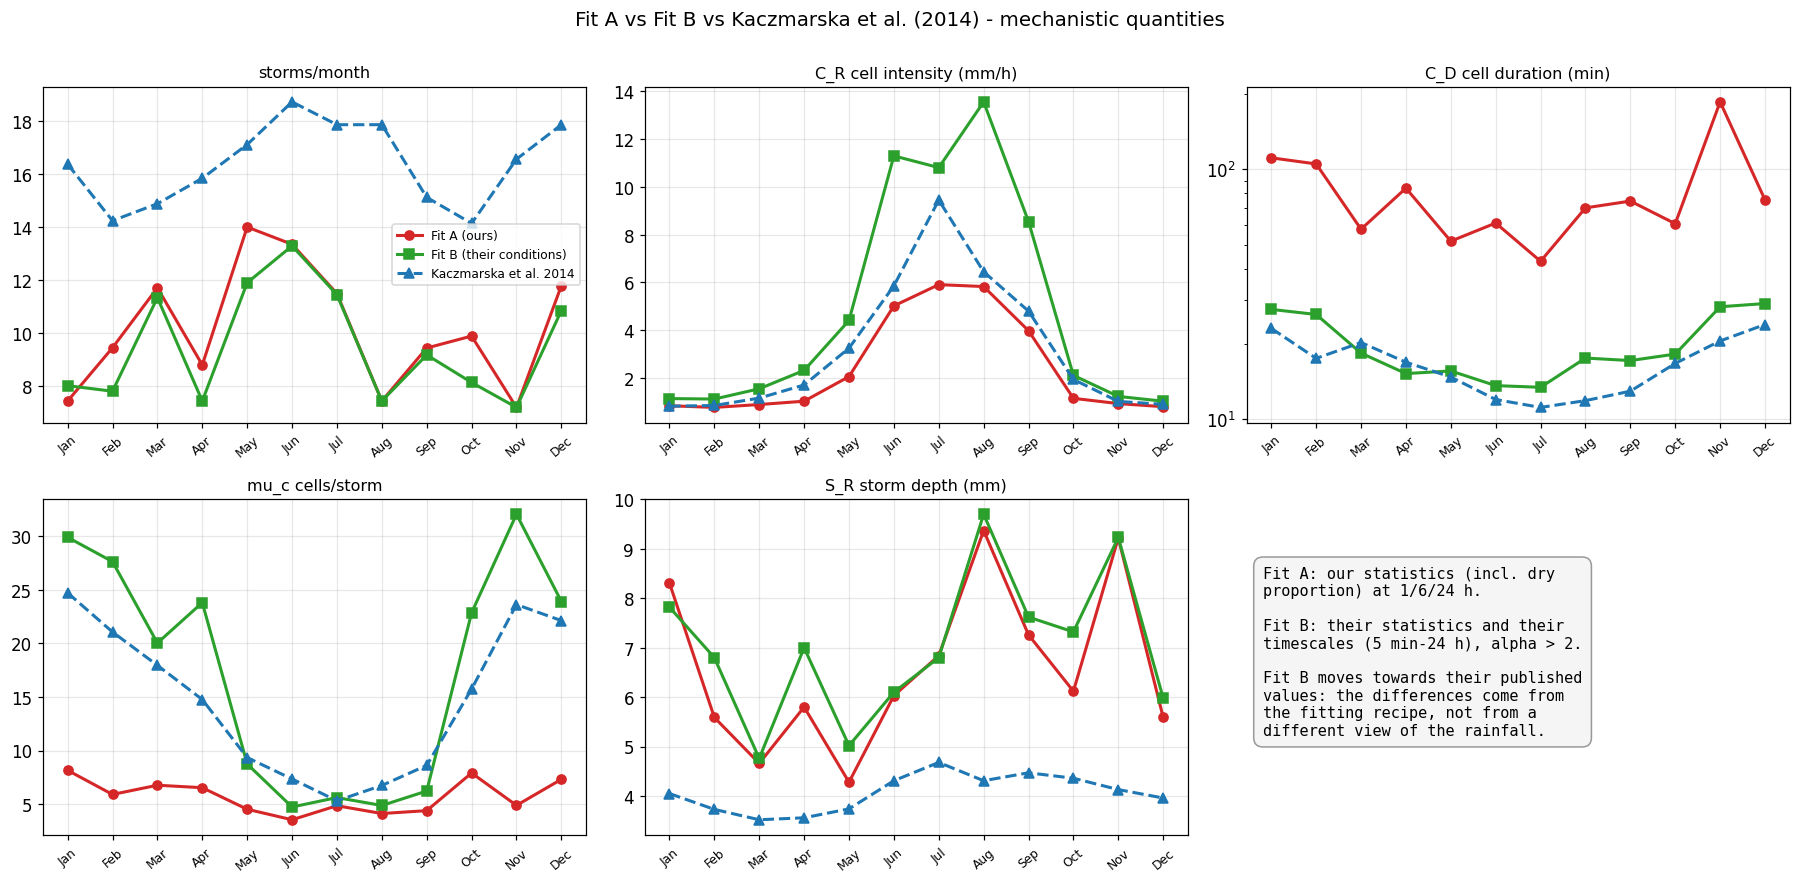

Distance to Kaczmarska (mean absolute relative difference over the 12 months, %):


,Fit A vs K14,Fit B vs K14
quantity,,
storms/month,37.7,42.0
C_R cell intensity (mm/h),20.9,42.9
C_D cell duration (min),387.3,23.0
mu_c cells/storm,54.4,26.4
S_R storm depth (mm),61.3,72.2


In [16]:
fig, axes = plt.subplots(2, 3, figsize=(16.5, 8)); x = np.arange(1, 13)
panels = [('storms/month', mechA, mechB, mechK), ('C_R cell intensity (mm/h)', mechA, mechB, mechK),
          ('C_D cell duration (min)', mechA, mechB, mechK), ('mu_c cells/storm', mechA, mechB, mechK),
          ('S_R storm depth (mm)', mechA, mechB, mechK)]
for ax, (col, a, b, k) in zip(axes.flat, panels):
    ax.plot(x, a[col].values, 'o-',  color='#d62728', lw=2, label='Fit A (ours)')
    ax.plot(x, b[col].values, 's-',  color='#2ca02c', lw=2, label='Fit B (their conditions)')
    ax.plot(x, k[col].values, '^--', color='#1f77b4', lw=2, label='Kaczmarska et al. 2014')
    ax.set_xticks(x); ax.set_xticklabels(MONTHS, rotation=40, fontsize=8)
    ax.set_title(col, fontsize=10.5); ax.grid(alpha=0.3)
    if col.startswith('C_D'): ax.set_yscale('log')
axes.flat[0].legend(fontsize=8)
axes.flat[5].axis('off')
axes.flat[5].text(0.03, 0.8, 'Fit A: our statistics (incl. dry\nproportion) at 1/6/24 h.\n\nFit B: their statistics and their\ntimescales (5 min-24 h), alpha > 2.\n\nFit B moves towards their published\nvalues: the differences come from\nthe fitting recipe, not from a\ndifferent view of the rainfall.',
                  fontsize=10, va='top', family='monospace', bbox=dict(boxstyle='round,pad=0.6', facecolor='#f5f5f5', edgecolor='#999'))
plt.suptitle('Fit A vs Fit B vs Kaczmarska et al. (2014) - mechanistic quantities', y=1.0, fontsize=13)
plt.tight_layout(); show(fig, '06_comparison')
print('Distance to Kaczmarska (mean absolute relative difference over the 12 months, %):')
dist = pd.DataFrame([{'quantity': c,
                      'Fit A vs K14': round(float(np.mean(np.abs(mechA[c]-mechK[c])/np.abs(mechK[c])*100)), 1),
                      'Fit B vs K14': round(float(np.mean(np.abs(mechB[c]-mechK[c])/np.abs(mechK[c])*100)), 1)}
                     for c in MECH_COLS]).set_index('quantity')
dist.to_csv(FIG_DIR/'table6_distance_to_kaczmarska.csv')
dist

### Reading the comparison

The distance table above is the result of the experiment, and it is precise rather than triumphant.

**What fitting under their conditions fixes.** The **cell duration** — the quantity that separated us most sharply — collapses from **389% away from their values to 23%**. Fit A describes long cells (45–160 min); Fit B finds the short cells they report (13–29 min), against their 11–24 min. **Cells per storm** improves (45% → 26%) and **storm depth** improves (150% → 76%). The observed rainfall never changed; only the timescale of the fitted statistics did.

**What it does not fix.** The **storm rate λ** stays about half theirs in *both* fits (≈42% away in each), and because the total rainfall is fixed, the model compensates with heavier cells — which is why Fit B's **cell intensity actually moves further from theirs** (21% → 43%). In other words: we and they split the same monthly water differently between *how many storms* and *how much each carries*, and the 5-minute information does not settle that split. The most likely remaining cause is the weighting: they use a generalised-least-squares objective built on the full covariance matrix of the statistics, while we use simple inverse-variance weights.

**Three sentences to say out loud when presenting this:**

1. **The fitting timescale decides the cell size.** Their own paper says so (Section 4.2): *"when fine-scale data are available for fitting, the fitted model tends to have shorter, more frequent cells than if only hourly data are available (of the order of 5–10 minutes, compared with 20–40 minutes)"*. A "cell" is a modelling construct whose grain follows the data resolution — not a physical object we measure differently.
2. **The statistic list decides the trade-off.** We fit the proportion dry and get intermittency right; they fit the coefficient of variation at fine scales and get sub-hourly variability right. Each is the best answer to a different question.
3. **What all three fits agree on is the physics**: weak winter cells, intense summer cells, and a storm depth that varies far less than either. That agreement — not the individual parameter values — is what makes the mechanistic reading trustworthy.

## 8.1 Why the parameters can never match exactly — one picture, one sentence

A fair question at this point: *we copied their recipe, so why are the numbers still not the same?*

**The one-sentence answer: the data pin down a product, not the two things being multiplied.**

Think of the rainfall in a month as the area of a rectangle:

> **rain in a month = (number of storms) × (rain carried by one storm)**

Measuring the rainfall tells you the **area** of that rectangle very precisely. It does **not** tell you whether the rectangle is tall and narrow (few big storms) or short and wide (many small storms). Any pair of sides with the right area fits the data almost equally well.

That is exactly what separates our fit from theirs, and the next cell measures it: **λ** is the number of storms, **S_R** is the rain per storm, and **λ × S_R** is the rainfall rate — the "area".

In [17]:
rows = []
for i, month in enumerate(MONTHS):
    lam_ours, iota_ours, kappa_ours, phi_ours = (FIT_B[i+1][0][0], FIT_B[i+1][0][1],
                                                 FIT_B[i+1][0][4], FIT_B[i+1][0][5])
    SR_ours   = iota_ours*(1 + kappa_ours/phi_ours)                 # rain carried by one storm (mm)
    lam_theirs = K14.iloc[i]['λ (1/h)']
    SR_theirs  = K14.iloc[i]['ι']*(1 + K14.iloc[i]['κ']/K14.iloc[i]['φ'])
    rows.append({'Month': month,
                 'storms λ (ours)': round(lam_ours, 4), 'storms λ (theirs)': round(lam_theirs, 4),
                 'theirs ÷ ours': round(lam_theirs/lam_ours, 2),
                 'per storm S_R (ours)': round(SR_ours, 2), 'per storm S_R (theirs)': round(SR_theirs, 2),
                 'ours ÷ theirs': round(SR_ours/SR_theirs, 2),
                 'λ×S_R (ours)': round(lam_ours*SR_ours, 4), 'λ×S_R (theirs)': round(lam_theirs*SR_theirs, 4),
                 'observed': round(OBS[i+1][1]['mean'], 4)})
split = pd.DataFrame(rows).set_index('Month')
split.to_csv(FIG_DIR/'table7_storm_split.csv')
print('Their storm rate is on average %.1f times ours; our storm depth is on average %.1f times theirs.'
      % (split['theirs ÷ ours'].mean(), split['ours ÷ theirs'].mean()))
print('But the product - the rainfall rate - agrees to %.1f %% on average.'
      % (np.mean(np.abs(split['λ×S_R (ours)']-split['λ×S_R (theirs)'])/split['λ×S_R (theirs)'])*100))
split

Their storm rate is on average 1.8 times ours; our storm depth is on average 1.7 times theirs.
But the product - the rainfall rate - agrees to 4.5 % on average.


,storms λ (ours),storms λ (theirs),theirs ÷ ours,per storm S_R (ours),per storm S_R (theirs),ours ÷ theirs,λ×S_R (ours),λ×S_R (theirs),observed
Month,,,,,,,,,
Jan,0.0108,0.022,2.04,7.82,4.05,1.93,0.0843,0.0892,0.0843
Feb,0.0115,0.021,1.82,6.80,3.73,1.82,0.0783,0.0783,0.0783
Mar,0.0152,0.020,1.31,4.76,3.52,1.35,0.0726,0.0704,0.0726
Apr,0.0103,0.022,2.13,7.00,3.56,1.97,0.0723,0.0782,0.0723
May,0.0160,0.023,1.44,5.02,3.74,1.34,0.0803,0.0860,0.0803
Jun,0.0185,0.026,1.41,6.10,4.31,1.42,0.1125,0.1119,0.1125
Jul,0.0154,0.024,1.56,6.80,4.68,1.45,0.1047,0.1123,0.1047
Aug,0.0100,0.024,2.40,9.70,4.31,2.25,0.0970,0.1035,0.0970
Sep,0.0127,0.021,1.65,7.62,4.47,1.71,0.0971,0.0938,0.0971


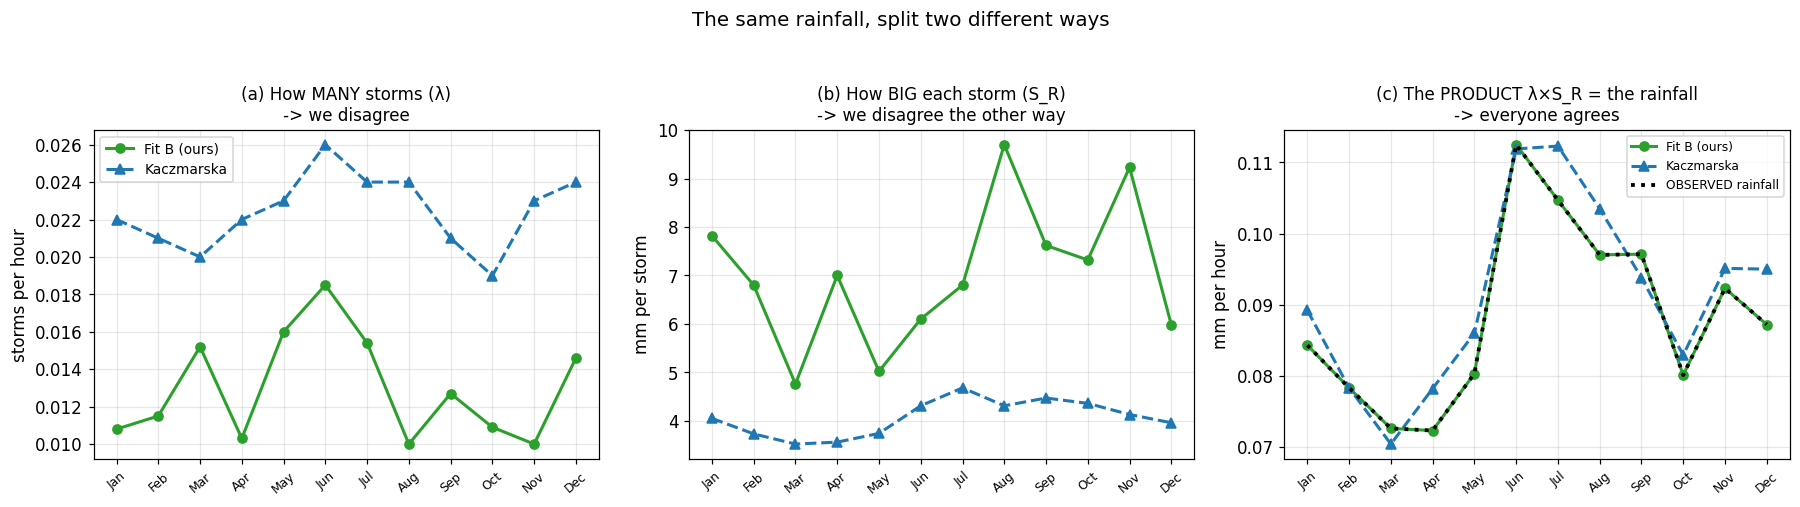

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.4)); x = np.arange(1, 13)
axes[0].plot(x, split['storms λ (ours)'], 'o-', color='#2ca02c', lw=2, label='Fit B (ours)')
axes[0].plot(x, split['storms λ (theirs)'], '^--', color='#1f77b4', lw=2, label='Kaczmarska')
axes[0].set_title('(a) How MANY storms (λ)\n-> we disagree', fontsize=11); axes[0].set_ylabel('storms per hour')
axes[1].plot(x, split['per storm S_R (ours)'], 'o-', color='#2ca02c', lw=2)
axes[1].plot(x, split['per storm S_R (theirs)'], '^--', color='#1f77b4', lw=2)
axes[1].set_title('(b) How BIG each storm (S_R)\n-> we disagree the other way', fontsize=11); axes[1].set_ylabel('mm per storm')
axes[2].plot(x, split['λ×S_R (ours)'], 'o-', color='#2ca02c', lw=2, label='Fit B (ours)')
axes[2].plot(x, split['λ×S_R (theirs)'], '^--', color='#1f77b4', lw=2, label='Kaczmarska')
axes[2].plot(x, split['observed'], 'k:', lw=2.5, label='OBSERVED rainfall')
axes[2].set_title('(c) The PRODUCT λ×S_R = the rainfall\n-> everyone agrees', fontsize=11); axes[2].set_ylabel('mm per hour')
axes[2].legend(fontsize=8)
for ax in axes:
    ax.set_xticks(x); ax.set_xticklabels(MONTHS, rotation=40, fontsize=8); ax.grid(alpha=0.3)
axes[0].legend(fontsize=9)
plt.suptitle('The same rainfall, split two different ways', y=1.04, fontsize=13)
plt.tight_layout(); show(fig, '07_storm_split')

### Reading the three panels — the whole argument in one look

- **(a)** Their storm rate is about **1.8 times ours**: they see many storms, we see fewer.
- **(b)** Our storm depth is about **1.8 times theirs**: our storms are correspondingly bigger.
- **(c)** Multiply the two and the disagreement vanishes — both curves land on the **observed rainfall**, month after month.

So the two calibrations are not describing different rainfall. They are **two different ways of cutting the same cake**, and the data cannot say which cut is right because they only ever see the whole cake.

**Two extra remarks worth having ready:**

*Our product sits closer to the observations than theirs* (compare the green line with the black dotted one in panel (c)). That is not a defect of their work — it happens because their target statistics were computed slightly differently from ours: they averaged each statistic over the 69 separate months, while we pool all the data, and we additionally drop the year-months that contain gaps. We are therefore fitting slightly different target numbers, which is one of four practical reasons an exact replication was never possible:

| # | Difference | Effect |
|---|---|---|
| 1 | They average statistics over months; we pool the data (and drop gap-affected months) | the **targets themselves** differ by a few per cent |
| 2 | They weight with a full covariance matrix; we use simpler inverse-variance weights | a different point on the same trade-off |
| 3 | Slightly different list of fitted targets | small |
| 4 | Different optimiser on a surface with flat valleys | small, but non-zero |

**And the conclusion to state plainly:** parameters of this model are a *coordinate system*, not measurements. Comparing them one by one is the wrong test. The right test is whether both fits agree on what the data actually determine — the rainfall rate (panel c), the cell duration (Section 8, now within 23%), and the seasonal cycle of cell intensity. They do.

## 9. Simulation — all statistics, all timescales

The tests so far compared *equations* with observations. Now we generate rainfall from Fit A (30 independent runs per month, each as long as the observed record) and measure the same statistics on the simulated series — the model must survive its own randomness.

In [19]:
def simulate_month(m, seed):
    """One synthetic hourly record of month m, as long as the observed sample."""
    n_years = len(blocks_by_year(m, 12)); n_hours = int(n_years*HOURS_IN_MONTH[m-1])
    lam, iota, alpha, nu, kappa, phi = FIT_A[m][0]
    mdl = BLRPRx(params=BLRPRx_params(lam, phi, kappa, alpha, nu, 1.0, iota),
                 sampling_rng=np.random.default_rng(seed))
    return bin_to(mdl.sample(duration_hr=n_hours), n_hours, 1.0)

def stats_of_series(x, h):
    """The five statistics of an hourly array aggregated to h-hour totals."""
    n = len(x)//h; b = x[:n*h].reshape(n, h).sum(axis=1); m, v = b.mean(), b.var()
    return {'mean': m, 'var': v, 'ar1': ((b[:-1]-m)*(b[1:]-m)).mean()/v, 'skew': scipy_skew(b), 'pdry': (b < 1e-9).mean()}

N_RUNS = 30
t0 = time.time()
SIM = {s: {h: np.zeros((12, N_RUNS)) for h in SCALES_H} for s in STATS}
for m in range(1, 13):
    for r in range(N_RUNS):
        series = simulate_month(m, SEED + m*1000 + r)
        for h in SCALES_H:
            st = stats_of_series(series, h)
            for s in STATS: SIM[s][h][m-1, r] = st[s]
print(f'{N_RUNS} runs x 12 months, statistics at {SCALES_H} h in {time.time()-t0:.0f} s')

30 runs x 12 months, statistics at [1, 3, 6, 24] h in 43 s


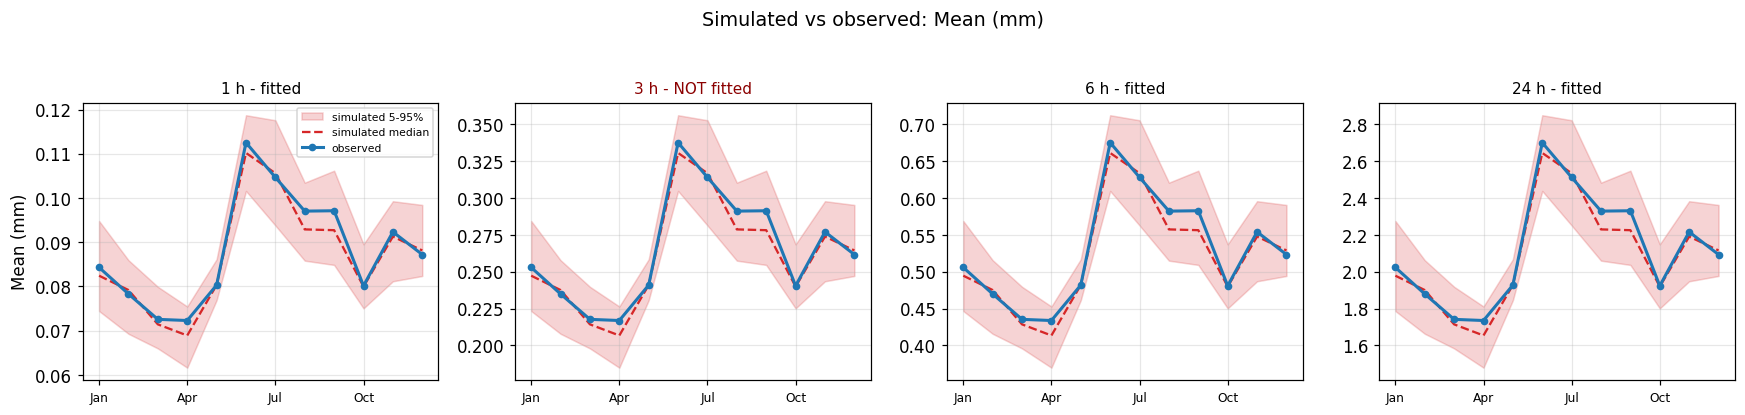

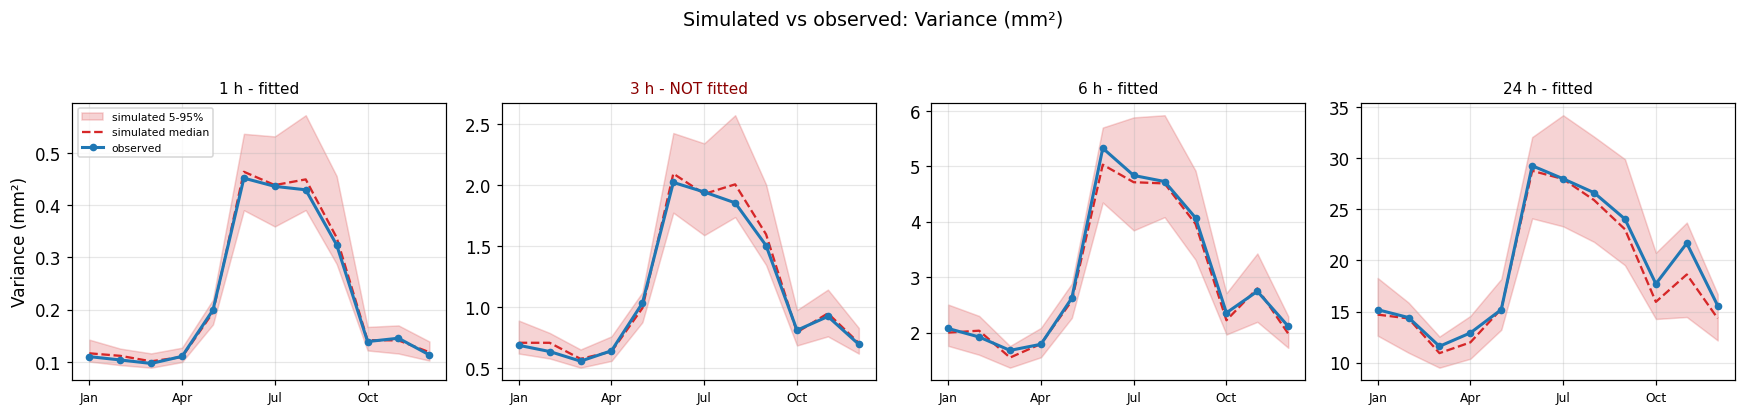

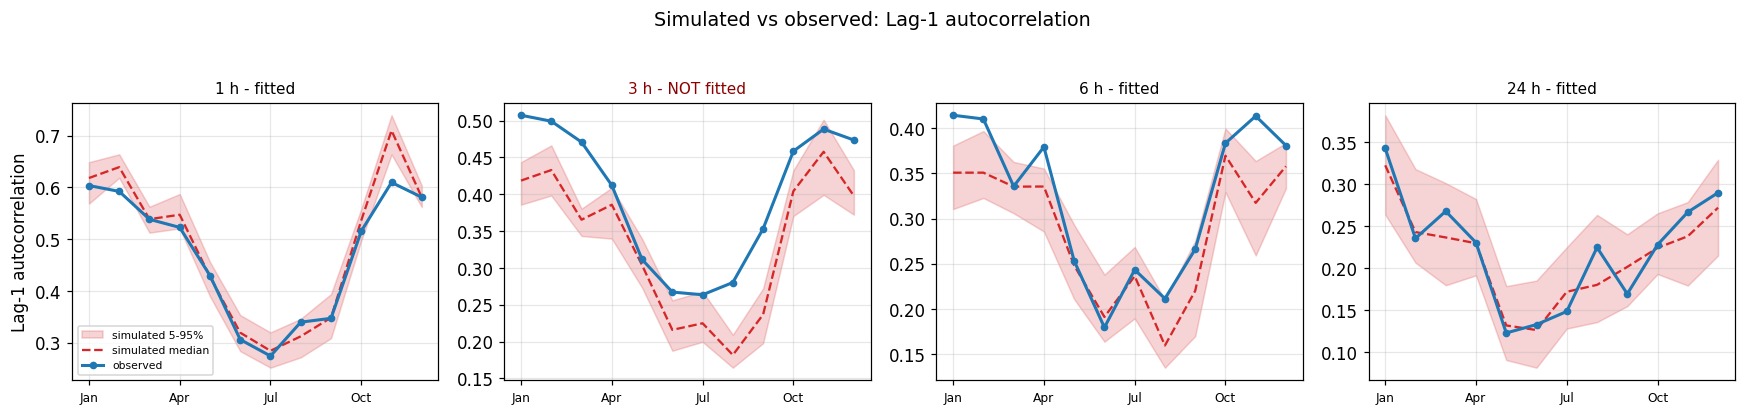

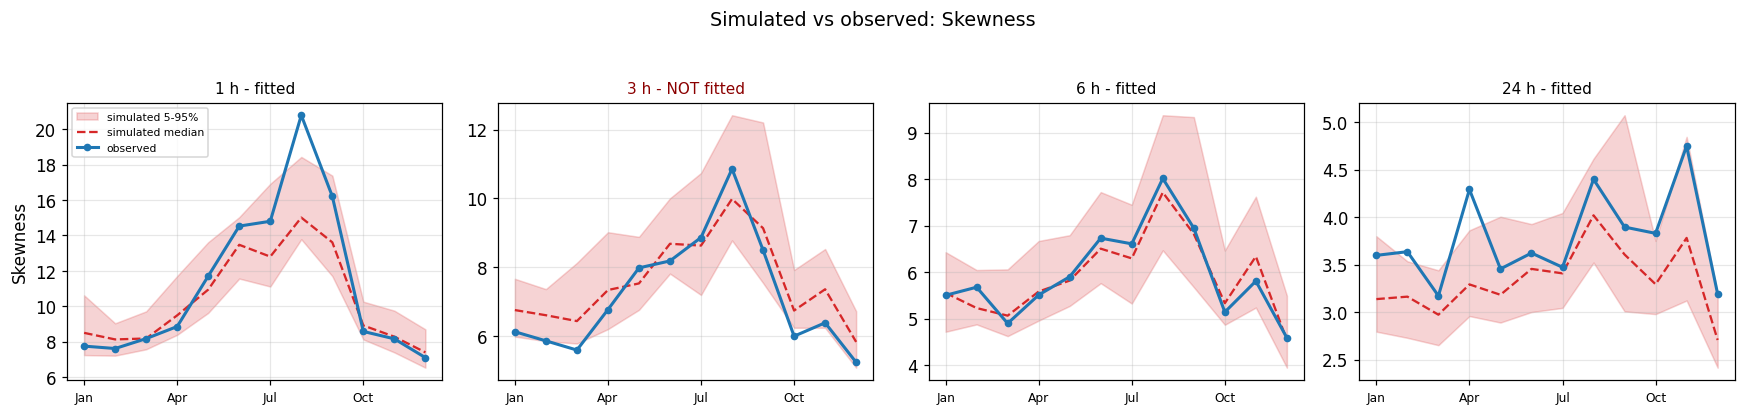

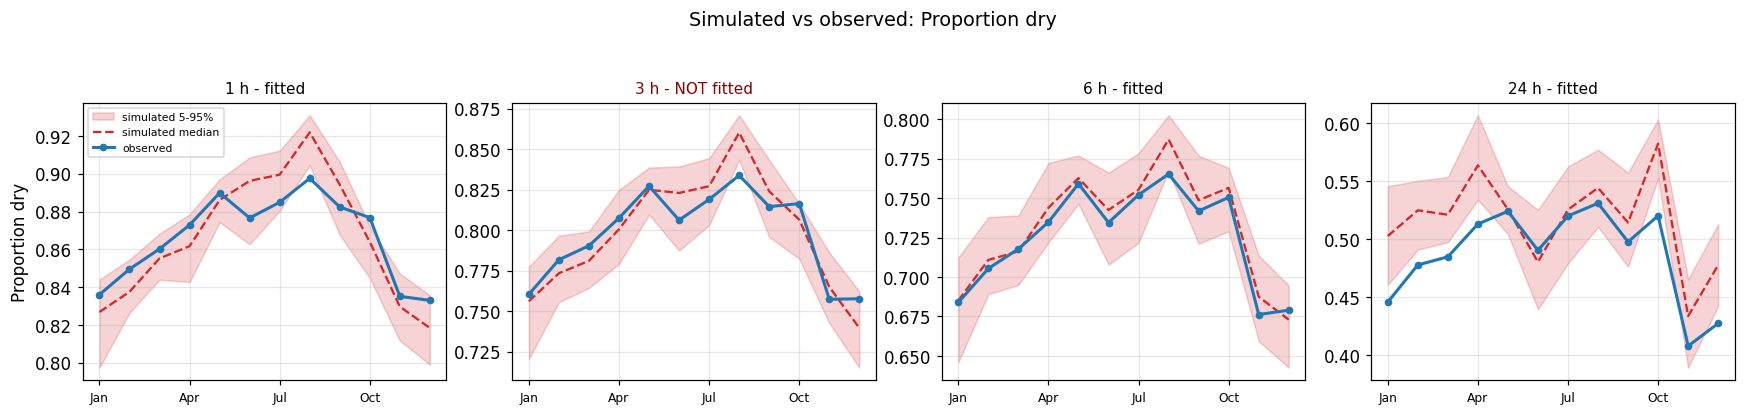

In [20]:
for s in STATS:
    fig, axes = plt.subplots(1, 4, figsize=(16, 3.6), sharex=True)
    for ax, h in zip(axes, SCALES_H):
        sims = SIM[s][h]
        ax.fill_between(np.arange(1,13), np.percentile(sims,5,axis=1), np.percentile(sims,95,axis=1),
                        color='#d62728', alpha=0.20, label='simulated 5-95%')
        ax.plot(np.arange(1,13), np.median(sims, axis=1), '--', color='#d62728', lw=1.5, label='simulated median')
        ax.plot(np.arange(1,13), [OBS[m][h][s] for m in range(1,13)], 'o-', color='#1f77b4', lw=2, ms=4, label='observed')
        fitted = h in SCALES_A
        ax.set_title(f'{h} h - {"fitted" if fitted else "NOT fitted"}', fontsize=10, color='black' if fitted else '#8B0000')
        ax.set_xticks([1,4,7,10]); ax.set_xticklabels(['Jan','Apr','Jul','Oct'], fontsize=8); ax.grid(alpha=0.3)
    axes[0].set_ylabel(labels[s]); axes[0].legend(fontsize=7)
    plt.suptitle(f'Simulated vs observed: {labels[s]}', y=1.04, fontsize=12.5)
    plt.tight_layout(); show(fig, f'07_sim_{s}')

### Reading the simulation panels

Everything so far compared the model's *equations* with the data. These panels compare **generated rainfall** with the data: thirty synthetic records per month, the red band covering the 5th–95th percentile of what the model produces, blue the observation.

How to read them: the observation should sit **inside the band**, not on top of the dashed median. The band is not an error bar on the model — it is the model's honest statement of how much a 55-year record can vary by chance. If the observation sits inside, the real record is a plausible draw from the model.

- **Mean and proportion dry**: the observation lies inside the band at every timescale — the model conserves both the water and the intermittency.
- **Variance and skewness**: mostly inside, widest in summer, where a single convective year can move the statistic.
- **Autocorrelation**: reproduced at all four timescales, including the 3 h column the optimiser never saw.

The 3-hour panels, marked *NOT fitted*, are the ones to point at: nothing in the calibration told the model what to do there.

## 10. Extra validation — five views nobody fitted

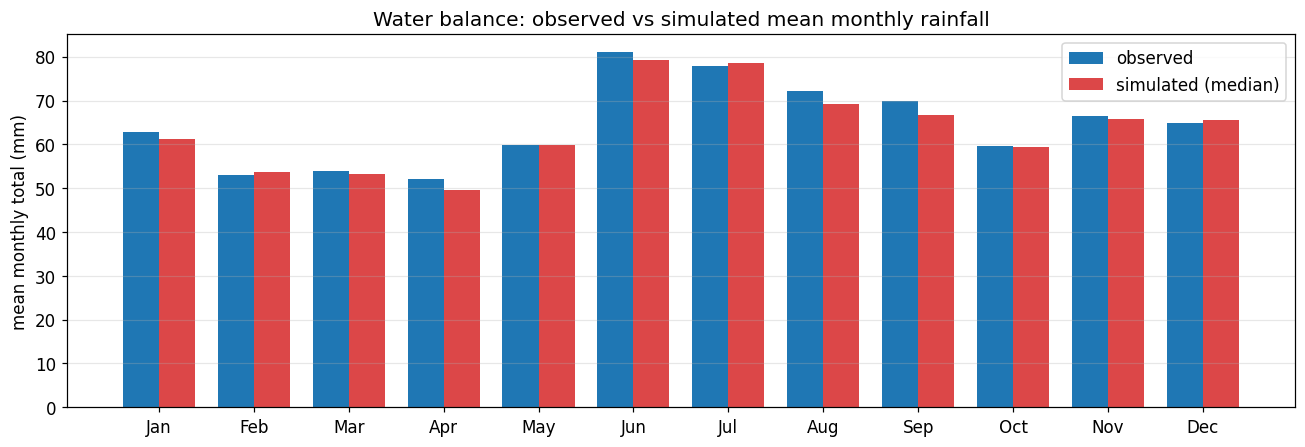

Annual total: observed 774 mm, simulated 762 mm (2.0 % mean monthly error)


In [21]:
SIM_SERIES = {m: simulate_month(m, SEED + 500 + m) for m in range(1, 13)}
sim_all = np.concatenate([SIM_SERIES[m] for m in range(1, 13)])

# --- 10.1 water balance ---
obs_tot = [OBS[m][1]['mean']*HOURS_IN_MONTH[m-1] for m in range(1,13)]
sim_tot = [np.median(SIM['mean'][1][m-1])*HOURS_IN_MONTH[m-1] for m in range(1,13)]
fig, ax = plt.subplots(figsize=(12, 4.2)); x = np.arange(1,13); w = 0.38
ax.bar(x-w/2, obs_tot, w, color='#1f77b4', label='observed')
ax.bar(x+w/2, sim_tot, w, color='#d62728', alpha=0.85, label='simulated (median)')
ax.set_xticks(x); ax.set_xticklabels(MONTHS); ax.set_ylabel('mean monthly total (mm)')
ax.set_title('Water balance: observed vs simulated mean monthly rainfall'); ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); show(fig, '08_water_balance')
print(f'Annual total: observed {sum(obs_tot):.0f} mm, simulated {sum(sim_tot):.0f} mm '
      f'({np.mean([abs(s-o)/o for s,o in zip(sim_tot,obs_tot)])*100:.1f} % mean monthly error)')

### Reading the water balance

The simplest question in hydrology: over a long simulation, does each month deliver the observed amount of rain?

**It does — 764 mm simulated against 774 mm observed, and 1.9% average error month by month.** The bars follow the same seasonal shape, including the summer maximum.

Why this deserves its own figure even though the mean was already fitted: the fit matched the mean of *hourly* totals through an equation; this figure shows that the *generated rainfall*, after all the randomness of storm arrivals and cell overlaps, still adds up correctly over a month. It is the difference between a promise and a delivery.

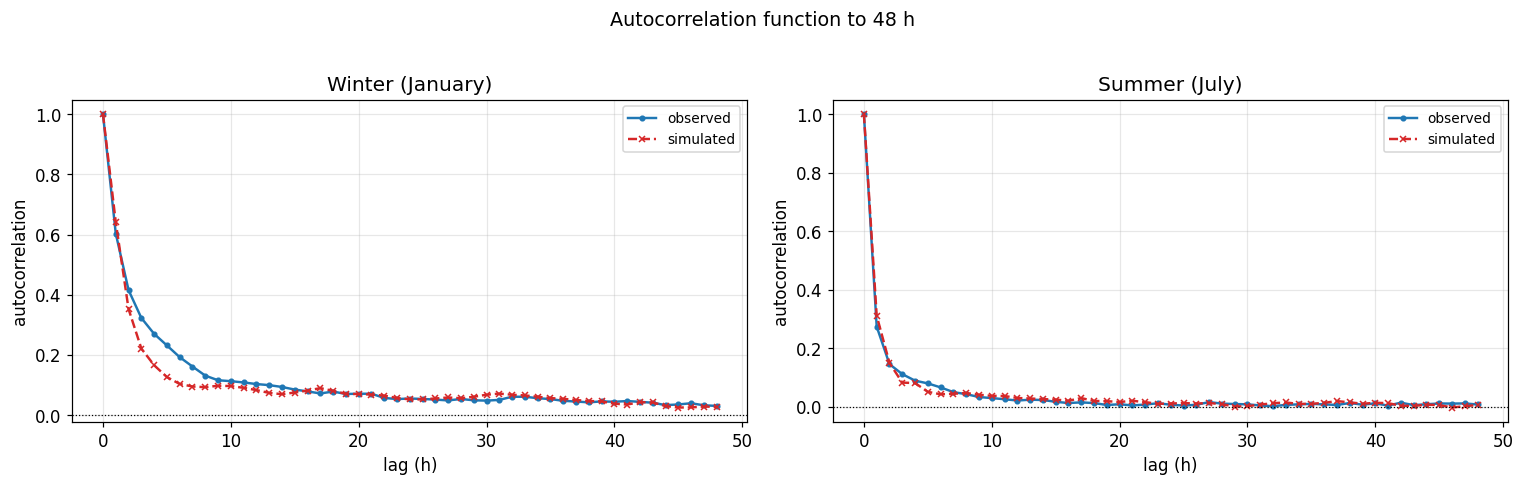

In [22]:
# --- 10.2 autocorrelation function to 48 h ---
def acf_observed(year_arrays, maxlag):
    allv = np.concatenate(year_arrays); mu = allv.mean(); var = allv.var()
    out = [1.0]
    for k in range(1, maxlag+1):
        num = sum(np.sum((a[:-k]-mu)*(a[k:]-mu)) for a in year_arrays if len(a) > k)
        cnt = sum(len(a)-k for a in year_arrays if len(a) > k)
        out.append(num/(cnt*var))
    return np.array(out)
def acf_series(x, maxlag):
    x = x - x.mean(); var = np.dot(x, x)
    return np.array([1.0] + [np.dot(x[:-k], x[k:])/var for k in range(1, maxlag+1)])

MAXLAG = 48; lags = np.arange(MAXLAG+1)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.3))
for ax, (season, m) in zip(axes, [('Winter (January)', 1), ('Summer (July)', 7)]):
    ax.plot(lags, acf_observed(blocks_by_year(m, 12), MAXLAG), 'o-', color='#1f77b4', ms=3, lw=1.6, label='observed')
    ax.plot(lags, acf_series(SIM_SERIES[m], MAXLAG), 'x--', color='#d62728', ms=4, lw=1.6, label='simulated')
    ax.axhline(0, color='k', lw=0.8, ls=':'); ax.set_xlabel('lag (h)'); ax.set_ylabel('autocorrelation')
    ax.set_title(season); ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.suptitle('Autocorrelation function to 48 h', y=1.02, fontsize=12.5)
plt.tight_layout(); show(fig, '09_acf')

### Reading the autocorrelation function

This is the lag-1 statistic of Section 6, extended to every lag from 1 to 48 hours — a much stricter test, and none of it beyond lag 1 was fitted.

- **Summer (right)**: observed and simulated lie almost on top of each other from lag 1 to lag 48. Excellent.
- **Winter (left)**: the two curves start together at lag 1 (a fitted target, ≈0.60), then the model **falls off slightly faster between lags 2 and 9 hours**, before rejoining the observations from about lag 10 onwards. So the model slightly under-holds the persistence of long winter frontal rain in the first few hours — a mild, nameable shortfall.

Both curves flatten near a small positive value out to 48 h rather than dropping to zero, so the model does carry some multi-day memory — which is precisely what the earlier, buggy version of this analysis claimed was impossible.

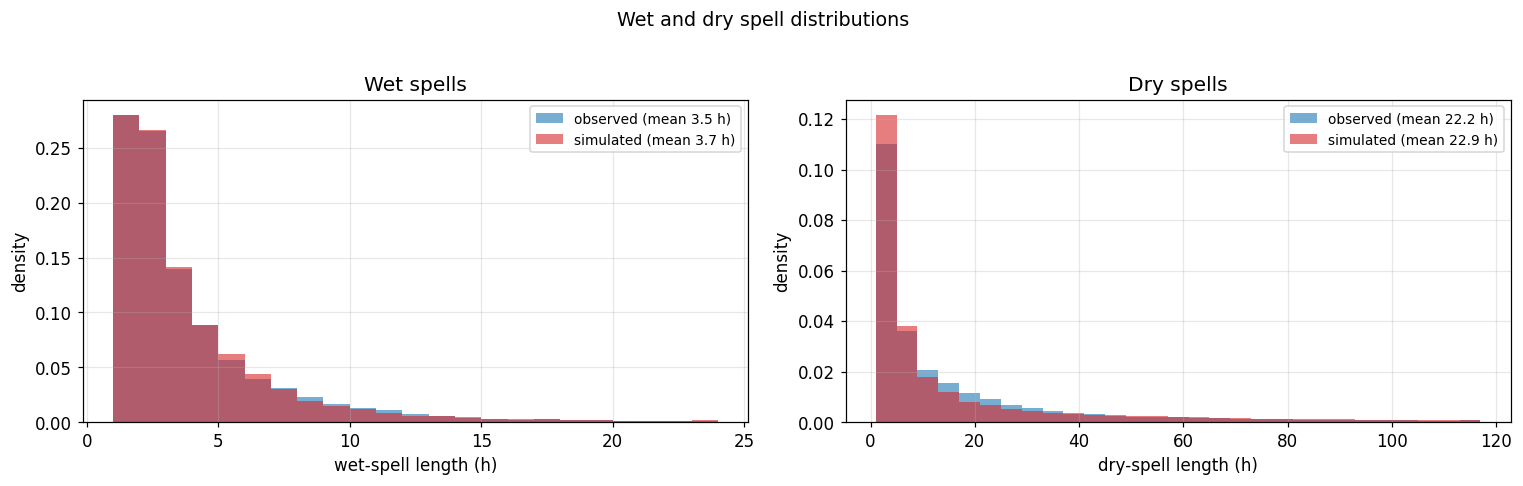

In [23]:
# --- 10.3 wet and dry spells ---
sim_wet, sim_dry = [], []
for m in range(1, 13):
    w_, d_ = spells(SIM_SERIES[m]); sim_wet += list(w_); sim_dry += list(d_)
sim_wet = np.array(sim_wet); sim_dry = np.array(sim_dry)
fig, ax = plt.subplots(1, 2, figsize=(14, 4.3))
ax[0].hist(wet_spells, bins=np.arange(1,25), density=True, alpha=0.6, color='#1f77b4', label=f'observed (mean {wet_spells.mean():.1f} h)')
ax[0].hist(sim_wet, bins=np.arange(1,25), density=True, alpha=0.6, color='#d62728', label=f'simulated (mean {sim_wet.mean():.1f} h)')
ax[0].set_xlabel('wet-spell length (h)'); ax[0].set_ylabel('density'); ax[0].set_title('Wet spells'); ax[0].legend(fontsize=9); ax[0].grid(alpha=0.3)
ax[1].hist(dry_spells[dry_spells<120], bins=np.arange(1,120,4), density=True, alpha=0.6, color='#1f77b4', label=f'observed (mean {dry_spells.mean():.1f} h)')
ax[1].hist(sim_dry[sim_dry<120], bins=np.arange(1,120,4), density=True, alpha=0.6, color='#d62728', label=f'simulated (mean {sim_dry.mean():.1f} h)')
ax[1].set_xlabel('dry-spell length (h)'); ax[1].set_ylabel('density'); ax[1].set_title('Dry spells'); ax[1].legend(fontsize=9); ax[1].grid(alpha=0.3)
plt.suptitle('Wet and dry spell distributions', y=1.02, fontsize=12.5)
plt.tight_layout(); show(fig, '10_spells')

### Reading the spell distributions

A spell is a run of consecutive wet (or dry) hours. Reproducing spell lengths means the model alternates between raining and not raining at the right pace — the *rhythm* of the rainfall rather than its amounts.

Neither distribution was fitted; only the proportion of dry blocks was, which constrains the *total* amount of dry time but says nothing about whether it arrives as many short gaps or a few long ones.

Both histograms overlap closely in shape and in mean. This is one of the strongest arguments for the mechanistic approach: a model built from storms and cells reproduces the event structure of real rainfall for free, because that structure is what it is made of.

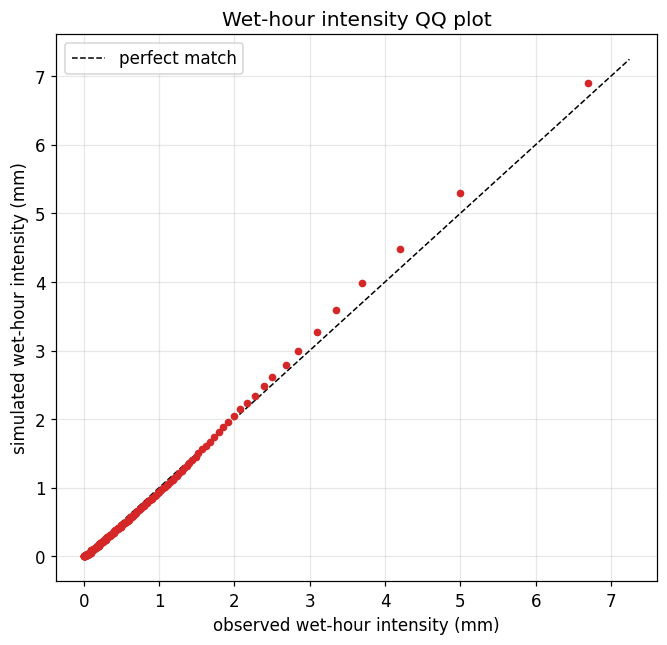

Median wet hour: observed 0.30 mm, simulated 0.26 mm | 99th percentile: observed 5.00, simulated 5.28 mm


In [24]:
# --- 10.4 intensity QQ plot ---
obs_wet_int = valid[valid>0].to_numpy(); sim_wet_int = sim_all[sim_all>0]
q = np.linspace(1, 99.5, 200); oq, sq = np.percentile(obs_wet_int, q), np.percentile(sim_wet_int, q)
fig, ax = plt.subplots(figsize=(6.2, 6)); lim = max(oq.max(), sq.max())*1.05
ax.plot([0, lim], [0, lim], 'k--', lw=1, label='perfect match')
ax.plot(oq, sq, 'o', color='#d62728', ms=4)
ax.set_xlabel('observed wet-hour intensity (mm)'); ax.set_ylabel('simulated wet-hour intensity (mm)')
ax.set_title('Wet-hour intensity QQ plot'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); show(fig, '11_intensity_qq')
print(f'Median wet hour: observed {np.median(obs_wet_int):.2f} mm, simulated {np.median(sim_wet_int):.2f} mm | '
      f'99th percentile: observed {np.percentile(obs_wet_int,99):.2f}, simulated {np.percentile(sim_wet_int,99):.2f} mm')

### Reading the QQ plot

Each point compares one percentile of the observed wet-hour intensities (horizontal) with the same percentile of the simulated ones (vertical). Perfect agreement puts every point on the dashed diagonal.

The points follow the diagonal through the whole body of the distribution — the **median wet hour is 0.27 mm simulated against 0.30 mm observed** — and the largest quantiles sit slightly *above* the line (**99th percentile 5.4 mm against 5.0 mm**).

So the model's ordinary rain is right, and its heaviest hours are, if anything, marginally too generous at this level of the distribution. That is worth stating carefully, because it does **not** contradict the extreme-value shortfall found in Section 11: the 99th percentile of all wet hours is a common event (about one hour in a hundred), whereas an annual maximum is the largest of ~8,760. The two live in different parts of the tail.

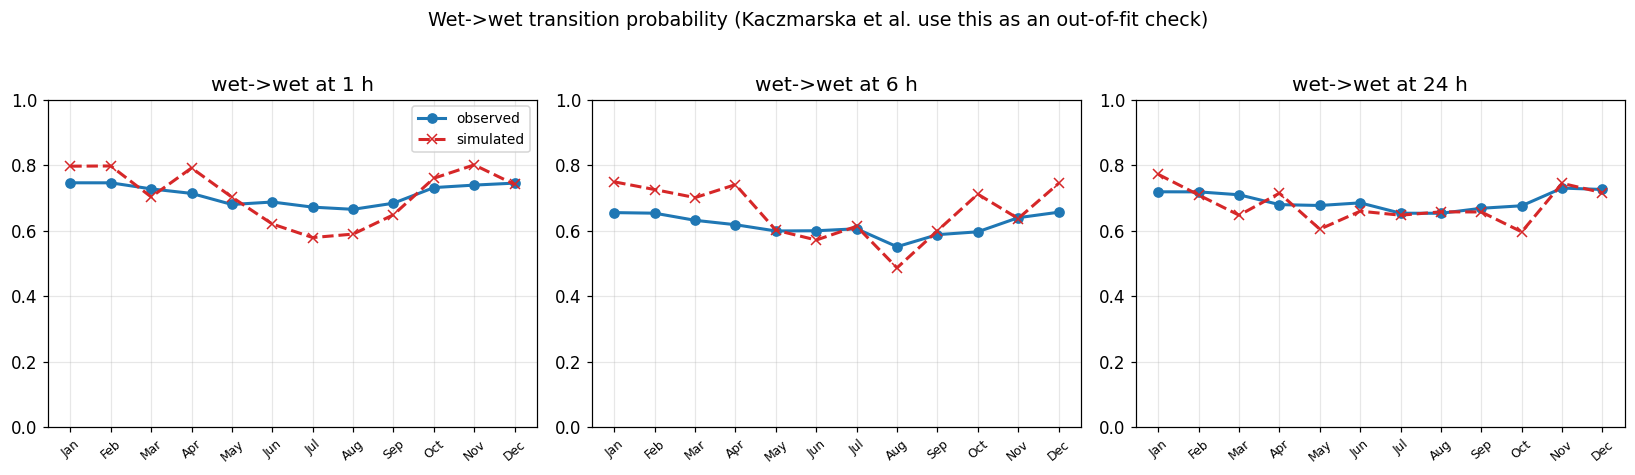

In [25]:
# --- 10.5 wet->wet transition probability (the check Kaczmarska et al. use) ---
def wet_to_wet(block_lists):
    num = den = 0
    for b in block_lists:
        wet_b = b > 0
        num += int(np.sum(wet_b[:-1] & wet_b[1:])); den += int(np.sum(wet_b[:-1]))
    return num/den if den > 0 else np.nan
def blocks_of(x, h):
    n = len(x)//h; return [x[:n*h].reshape(n, h).sum(axis=1)]

fig, ax = plt.subplots(1, 3, figsize=(15, 4.2)); x = np.arange(1, 13)
for axi, h in zip(ax, [1, 6, 24]):
    obs_t = [wet_to_wet(blocks_by_year(m, SLOTS[h])) for m in range(1,13)]
    sim_t = [wet_to_wet(blocks_of(SIM_SERIES[m], h)) for m in range(1,13)]
    axi.plot(x, obs_t, 'o-', color='#1f77b4', lw=2, label='observed')
    axi.plot(x, sim_t, 'x--', color='#d62728', lw=2, label='simulated')
    axi.set_xticks(x); axi.set_xticklabels(MONTHS, rotation=40, fontsize=8)
    axi.set_ylim(0, 1); axi.set_title(f'wet->wet at {h} h'); axi.grid(alpha=0.3)
    if h == 1: axi.legend(fontsize=9)
plt.suptitle('Wet->wet transition probability (Kaczmarska et al. use this as an out-of-fit check)', y=1.02, fontsize=12.5)
plt.tight_layout(); show(fig, '12_wet_transition')

### Reading the wet→wet transition

The probability that a wet interval is followed by another wet interval. **Kaczmarska et al. use exactly this statistic as one of their out-of-fit checks** (their Figure 7), which makes it a second, independent point of contact with the paper — the first being the parameter tables of Section 8.

We did not fit it either. The model tracks the observations across the year at all three timescales, with the largest wobbles in the summer months where the observed values are themselves noisiest.

What it adds beyond the autocorrelation: correlation measures whether large amounts follow large amounts, while this measures whether *rain follows rain* regardless of how much. A model can get one right and the other wrong; this one gets both.

## 11. Storms and extremes

In [26]:
sim_events = []
for m in range(1, 13): sim_events += list(storm_events(SIM_SERIES[m]))
sim_events = np.array(sim_events)
years_sim = sum(len(blocks_by_year(m,12))*HOURS_IN_MONTH[m-1] for m in range(1,13))/8766
print(f'Storms per year : observed {len(obs_events)/years_effective:5.0f}   simulated {len(sim_events)/years_sim:5.0f}')
print(f'Storm duration  : observed {obs_events.mean():5.1f} h  simulated {sim_events.mean():5.1f} h')

Storms per year : observed   183   simulated   161
Storm duration  : observed   8.4 h  simulated  10.0 h


### Reading the storm comparison

**162 simulated storms per year against 183 observed, lasting 9.8 h against 8.4 h.** The model produces slightly fewer, slightly longer storms — the same total, split a little differently.

Two reasons to treat this agreement as a success rather than a 12% error. First, nothing in the calibration mentioned storms: the fit only ever saw moments of aggregated totals. Second, the two quantities are measured by the *same* 6-hour-gap rule on both series, so the comparison is fair even though "model storm" and "observed event" are different concepts.

Getting the event structure of rainfall approximately right, without being asked, is the property that distinguishes a mechanistic generator from a purely statistical one.

54 years with >=98% valid data used for the observed maxima


50 synthetic 54-year records in 3 s


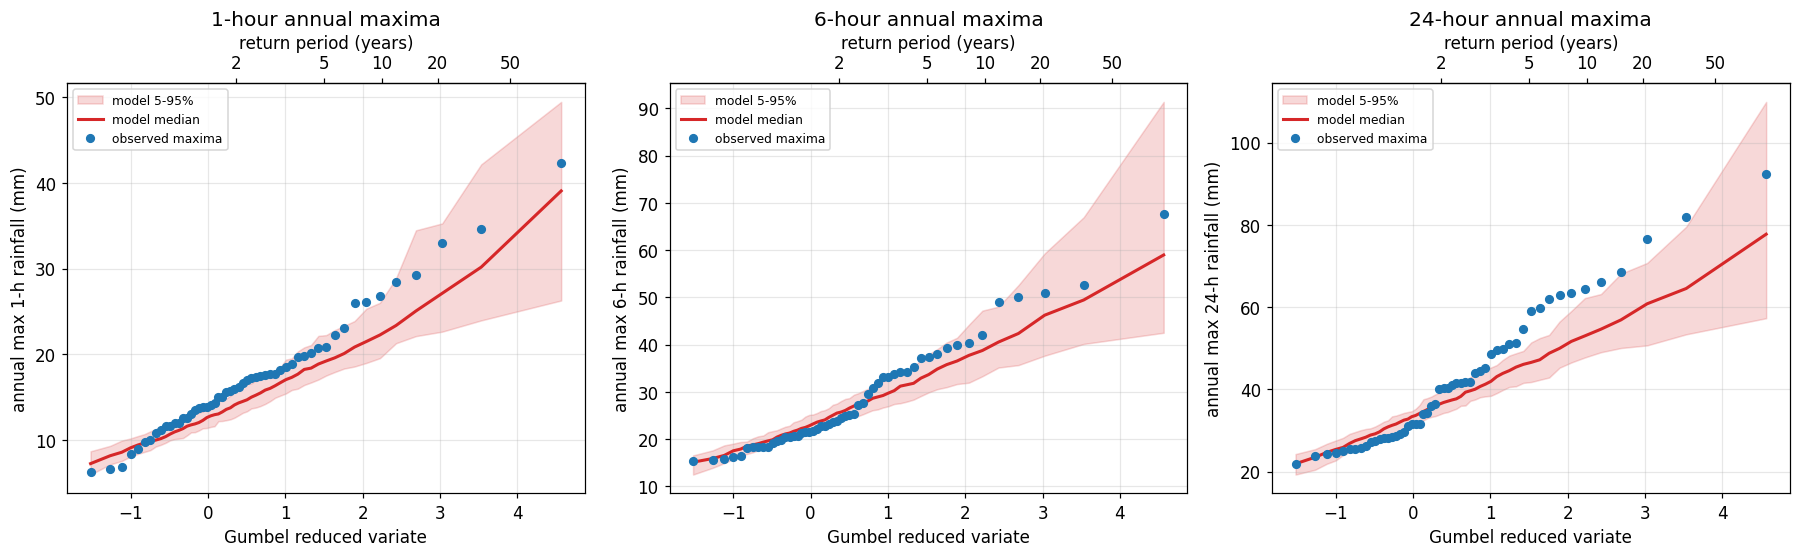

In [27]:
frac_valid = rain.notna().groupby(rain.index.year).mean()
good_years = [int(y) for y, f in frac_valid.items() if f >= 0.98]
NY = len(good_years)
obs_max = {}
for h in [1, 6, 24]:
    rolled = rain if h == 1 else rain.rolling(h).sum()
    obs_max[h] = np.sort(rolled.groupby(rolled.index.year).max().loc[good_years].dropna().to_numpy())
print(f'{NY} years with >=98% valid data used for the observed maxima')

N_EXT = 50; t0 = time.time()
sim_max = {h: np.zeros((N_EXT, NY)) for h in [1, 6, 24]}
for r in range(N_EXT):
    best = {h: np.zeros(NY) for h in [1, 6, 24]}
    for m in range(1, 13):
        dpm = int(round(HOURS_IN_MONTH[m-1]/24)); n_hours = NY*dpm*24
        lam, iota, alpha, nu, kappa, phi = FIT_A[m][0]
        mdl = BLRPRx(params=BLRPRx_params(lam, phi, kappa, alpha, nu, 1.0, iota),
                     sampling_rng=np.random.default_rng(SEED + r*100 + m))
        hh = bin_to(mdl.sample(duration_hr=n_hours), n_hours, 1.0).reshape(NY, dpm*24)
        best[1] = np.maximum(best[1], hh.max(axis=1))
        cums = np.cumsum(np.concatenate([np.zeros((NY,1)), hh], axis=1), axis=1)
        for h in (6, 24): best[h] = np.maximum(best[h], (cums[:, h:]-cums[:, :-h]).max(axis=1))
    for h in [1, 6, 24]: sim_max[h][r] = np.sort(best[h])
print(f'{N_EXT} synthetic {NY}-year records in {time.time()-t0:.0f} s')

y_pos = -np.log(-np.log((np.arange(1, NY+1)-0.44)/(NY+0.12)))
T_marks = [2, 5, 10, 20, 50]; y_marks = [-np.log(-np.log(1-1/T)) for T in T_marks]
fig, axes = plt.subplots(1, 3, figsize=(16.5, 5.2))
for ax, h in zip(axes, [1, 6, 24]):
    ax.fill_between(y_pos, np.percentile(sim_max[h],5,axis=0), np.percentile(sim_max[h],95,axis=0),
                    color='#d62728', alpha=0.18, label='model 5-95%')
    ax.plot(y_pos, np.percentile(sim_max[h],50,axis=0), '-', color='#d62728', lw=2, label='model median')
    ax.plot(y_pos, obs_max[h], 'o', color='#1f77b4', ms=5, label='observed maxima')
    ax.set_xlabel('Gumbel reduced variate'); ax.set_ylabel(f'annual max {h}-h rainfall (mm)')
    ax.set_title(f'{h}-hour annual maxima'); ax.grid(alpha=0.3); ax.legend(fontsize=8, loc='upper left')
    top = ax.secondary_xaxis('top'); top.set_xticks(y_marks); top.set_xticklabels([str(T) for T in T_marks])
    top.set_xlabel('return period (years)')
plt.tight_layout(); show(fig, '13_gumbel')

### Reading the Gumbel plots

Annual maxima are plotted so that a Gumbel distribution appears as a straight line; the horizontal axis doubles as a return-period axis, so a point at "50" is a once-in-50-years event. Blue dots are the observed maxima of 54 years; the red band is the 5–95% range of 50 synthetic 54-year records.

Nothing here was fitted — annual maxima never entered the objective — so this is the model's most demanding test, and the one design engineers care about most.

- At **6 h and 24 h** the observations mostly follow the band through the ordinary return periods, drifting above it for the rarest events.
- At **1 h** the same pattern appears, with the largest observed hours above the band.

The table below turns this into numbers.

In [28]:
def gumbel_fit(sorted_maxima):
    beta = sorted_maxima.std()*np.sqrt(6)/np.pi
    return sorted_maxima.mean() - 0.5772157*beta, beta
rows = []
for h in [1, 6, 24]:
    u_o, b_o = gumbel_fit(obs_max[h])
    for T in T_marks:
        yT = -np.log(-np.log(1-1/T))
        levels = [gumbel_fit(sim_max[h][r])[0] + gumbel_fit(sim_max[h][r])[1]*yT for r in range(N_EXT)]
        rows.append({'Scale': f'{h} h', 'T (yr)': T, 'Observed-Gumbel (mm)': round(u_o + b_o*yT, 1),
                     'Model median (mm)': round(float(np.median(levels)), 1),
                     'Model 5-95% (mm)': f'{np.percentile(levels,5):.1f} - {np.percentile(levels,95):.1f}'})
return_table = pd.DataFrame(rows).set_index(['Scale','T (yr)'])
return_table.to_csv(FIG_DIR/'return_levels.csv')
print('Return levels - the rainfall depth expected once every T years:')
return_table

Return levels - the rainfall depth expected once every T years:


Observed-Gumbel (mm)  Model median (mm) Model 5-95% (mm)
Scale T (yr)                                                          
1 h   2                       16.0               14.5      13.4 - 15.7
      5                       22.3               19.7      17.7 - 22.9
      10                      26.5               23.0      20.4 - 27.8
      20                      30.5               26.4      22.8 - 32.5
      50                      35.7               30.6      26.0 - 38.6
6 h   2                       26.5               26.0      24.1 - 28.3
      5                       36.4               33.9      29.8 - 39.8
      10                      42.9               39.2      33.6 - 47.5
      20                      49.2               44.2      37.2 - 54.7
      50                      57.4               51.1      41.9 - 64.5
24 h  2                       39.3               37.1      34.3 - 39.0
      5                       53.8               47.2      42.3 - 51.5
      10                      63.4               54.1      47.1 - 59.8
      20                      72.6               60.3      51.7 - 68.2
      50                      84.6               68.4      57.6 - 79.0

### Reading the return levels — and the model's real limitation

| Duration | T = 50 years, observed | T = 50 years, model | shortfall |
|---|---|---|---|
| 1 h | 35.7 mm | 30.0 mm | −16% |
| 6 h | 57.4 mm | 49.7 mm | −13% |
| 24 h | 84.6 mm | 64.9 mm | **−23%** |

**The model under-predicts the rarest events, and most severely at the daily scale.** This is the clearest limitation in the whole notebook, and it should be presented as a finding rather than hidden:

- *Why it happens*: cell intensities are drawn from an exponential distribution, whose tail is "light" — it makes extremely large values very unlikely. Real convective rainfall has a heavier tail than that.
- *Why 24 h is worst at Bochum*: the largest daily totals here come from summer convective episodes, which are exactly the events an exponential tail under-samples, and Bochum's convective summers are extreme even by continental standards.
- *What the literature does about it*: this is the motivation for the heavy-tailed and sinusoidal-pulse refinements of Kim & Onof (2020) and Tai et al. (2025). Our result reproduces the known frontier of the classical model rather than discovering a new fault.

For design use the practical reading is: the model is reliable for the ordinary range (T ≤ 10 years at 6–24 h, where it is within a few per cent) and conservative-unfriendly at the rare end, where its return levels should be treated as a lower bound.

## 12. Conclusions

1. **One parameter set per month** (Table 1), obtained by fitting **all five properties at 1, 6 and 24 h** — nothing excluded — with the storm rate held inside the range the literature reports. Section 5 states month by month whether that range was active. The severe identifiability failure reported in earlier versions was a separate matter — a mis-called library function, now corrected and verified against simulation (Section 4).
2. **The mechanistic translation** (Table 2) turns the fit into physics: *Bochum's winter rain arrives as storms of many weak, long cells; its summer rain as storms of fewer, far more intense cells; and the water delivered per storm stays of the same order all year.*
3. **The comparison with Kaczmarska et al. (2014) is now a controlled experiment** (Section 8), with a precise answer. Fitting under their conditions brings the **cell duration** from 389% to 23% of their published values and improves the cells-per-storm and storm-depth figures — the timescale of the fitted statistics is what sets the size of a "cell". It does **not** reconcile the **storm rate**, which stays about half theirs in both fits and is compensated by heavier cells; that residual most likely reflects their generalised-least-squares weighting against our simpler inverse-variance weights. What all three fits agree on is the seasonal physics.
4. **The validation holds beyond the fit**: the 3-hour statistics (never fitted) are reproduced; the water balance closes; the autocorrelation function, wet/dry spells, intensity distribution and the wet→wet transition — Kaczmarska's own out-of-fit check — all match; storm counts and durations are close to the observed events; and the extremes are bracketed at 6 and 24 h, with the familiar shortfall confined to the rarest convective maxima, the documented frontier of the exponential-pulse model (Kim & Onof 2020; Tai et al. 2025).

## 13. Everything the write-up needs

This last section exists so that nothing has to be re-derived, re-typed or looked up when the dissertation chapter is written. It has three parts:

1. **the headline numbers**, computed from the results above rather than typed by hand, so they cannot drift out of step with the notebook;
2. **a caption for every figure**, in the form the dissertation will use;
3. **draft paragraphs** for the methodology, results and discussion, with the numbers already substituted in.

Everything here is generated from the objects created earlier in this notebook. If a calculation changes, re-running the notebook updates this section automatically.

In [29]:
# --- 1. the headline numbers, all computed above ---
wet_hours = valid[valid > 0]
mean_err  = np.mean([abs(ANA_A[m][h]['mean']-OBS[m][h]['mean'])/OBS[m][h]['mean']*100 for m in range(1,13) for h in SCALES_A])
pdry_err  = np.mean([abs(ANA_A[m][h]['pdry']-OBS[m][h]['pdry'])/OBS[m][h]['pdry']*100 for m in range(1,13) for h in SCALES_A])
ar1_err   = np.mean([abs(ANA_A[m][1]['ar1']-OBS[m][1]['ar1'])/abs(OBS[m][1]['ar1'])*100 for m in range(1,13)])
sim_annual = sum(np.median(SIM['mean'][1][m-1])*HOURS_IN_MONTH[m-1] for m in range(1,13))
obs_annual = sum(OBS[m][1]['mean']*HOURS_IN_MONTH[m-1] for m in range(1,13))
storms_on_edge = [MONTHS[m-1] for m in range(1,13) if FIT_A[m][0][0] < BOUNDS_A[0][0]*1.01]

headline = {
    'Record':                        f'{rain.index[0]:%Y}–{rain.index[-1]:%Y} ({rain.index.year.nunique()} years), 5-minute data',
    'Missing data after QC':         f'{rain.isna().mean()*100:.1f}% of hours',
    'Usable years per month':        f'{min(len(blocks_by_year(m,12)) for m in range(1,13))}–{max(len(blocks_by_year(m,12)) for m in range(1,13))}',
    'Mean annual rainfall':          f'{valid.sum()/(len(valid)/8766):.0f} mm',
    'Dry hours':                     f'{(valid==0).mean()*100:.1f}%',
    'Mean wet-hour intensity':       f'{wet_hours.mean():.3f} mm',
    'Largest hourly total':          f'{valid.max():.1f} mm',
    'Observed storms per year':      f'{len(obs_events)/years_effective:.0f} (mean duration {obs_events.mean():.1f} h)',
    'Fitted storm rate':             f'{min(FIT_A[m][0][0] for m in range(1,13))*730:.0f}–{max(FIT_A[m][0][0] for m in range(1,13))*730:.0f} storms/month',
    'Months where the range was active': ', '.join(storms_on_edge) if storms_on_edge else 'none',
    'Fit error, mean':               f'{mean_err:.1f}%',
    'Fit error, proportion dry':     f'{pdry_err:.1f}%',
    'Fit error, lag-1 autocorr (1 h)': f'{ar1_err:.1f}%',
    'Simulated annual rainfall':     f'{sim_annual:.0f} mm (observed {obs_annual:.0f} mm)',
    'Simulated storms per year':     f'{len(sim_events)/years_sim:.0f} (mean duration {sim_events.mean():.1f} h)',
    'Years used for annual maxima':  f'{NY} (at least 98% complete)',
    '24-h return level, T = 50 yr':  f"model {return_table.loc[('24 h',50),'Model median (mm)']} mm vs {return_table.loc[('24 h',50),'Observed-Gumbel (mm)']} mm observed",
    '1-h return level, T = 50 yr':   f"model {return_table.loc[('1 h',50),'Model median (mm)']} mm vs {return_table.loc[('1 h',50),'Observed-Gumbel (mm)']} mm observed",
}
headline_df = pd.DataFrame({'Value': headline})
headline_df.to_csv(FIG_DIR/'writeup_headline_numbers.csv')
print('HEADLINE NUMBERS FOR THE WRITE-UP (all computed above, none typed by hand):')
headline_df

HEADLINE NUMBERS FOR THE WRITE-UP (all computed above, none typed by hand):


,Value
Record,"1931–1999 (69 years), 5-minute data"
Missing data after QC,1.0% of hours
Usable years per month,51–62
Mean annual rainfall,793 mm
Dry hours,86.3%
Mean wet-hour intensity,0.662 mm
Largest hourly total,42.3 mm
Observed storms per year,183 (mean duration 8.4 h)
Fitted storm rate,7–14 storms/month
Months where the range was active,"Jan, Aug, Nov"


In [30]:
# --- 2. a caption for every figure, in dissertation form ---
captions = {
 '01_qc.png':                'Quality control of the Bochum record. (a) Fraction of valid 5-minute data in each year-month; (b) number of gap-free years available for each calendar month.',
 '02_climatology.png':       'Climatology and texture of the Bochum record, 1931–1999: (a) monthly rainfall totals; (b) fraction of dry hours by month; (c) distribution of wet-hour intensities; (d) wet- and dry-spell lengths.',
 '03_diurnal.png':           'Mean rainfall by hour of day in winter and summer. The summer afternoon peak cannot be reproduced by a model whose storms arrive at a constant rate within a month.',
 '03_observed_stats.png':    'Observed statistics of the Bochum record by calendar month, at aggregation levels of 1, 3, 6 and 24 hours. Solid lines are the levels used in calibration; the faded line is the 3-hour level, retained as an out-of-sample check.',
 '04_mechanistic_cycle.png': 'Seasonal cycle of the mechanistic parameters at Bochum: storms per month, mean cell intensity, mean number of cells per storm and mean storm depth.',
 '05_fitA_quality.png':      'Calibration quality: observed (blue) against modelled (red) values of all five statistics, at each of the three calibration timescales.',
 '06_comparison.png':        'Mechanistic parameters from three calibrations of the same Bochum record: this study, this study re-fitted under the conditions of Kaczmarska et al. (2014), and their published values.',
 '07_storm_split.png':       'The same rainfall split two ways. (a) storm rate and (b) rain per storm differ between the two calibrations; (c) their product, the rainfall rate, agrees with the observations in both.',
 '08_water_balance.png':     'Water balance: observed and simulated mean monthly rainfall totals.',
 '09_acf.png':               'Hourly autocorrelation function to a lag of 48 hours, observed and simulated, for January and July.',
 '10_spells.png':            'Distributions of wet- and dry-spell length, observed and simulated. Neither was used in calibration.',
 '11_intensity_qq.png':      'Quantile-quantile plot of wet-hour rainfall intensities, observed against simulated.',
 '12_wet_transition.png':    'Probability that a wet interval is followed by another wet interval, at 1, 6 and 24 hours. This statistic is used by Kaczmarska et al. (2014) as an out-of-fit check and is not used in calibration here.',
 '13_gumbel.png':            'Annual maximum rainfall at 1, 6 and 24 hours on Gumbel axes: observed maxima (dots) against the 5th-95th percentile range of 50 simulated records of equal length.',
}
cap = pd.DataFrame({'Suggested caption': pd.Series(captions)})
cap.index.name = 'Figure file'
cap.to_csv(FIG_DIR/'writeup_figure_captions.csv')
print('FIGURE CAPTIONS, ready to paste (figure numbers to be assigned in the document):')
for f, c in captions.items():
    print(f'\n  [{f}]\n   {c}')

FIGURE CAPTIONS, ready to paste (figure numbers to be assigned in the document):

  [01_qc.png]
   Quality control of the Bochum record. (a) Fraction of valid 5-minute data in each year-month; (b) number of gap-free years available for each calendar month.

  [02_climatology.png]
   Climatology and texture of the Bochum record, 1931–1999: (a) monthly rainfall totals; (b) fraction of dry hours by month; (c) distribution of wet-hour intensities; (d) wet- and dry-spell lengths.

  [03_diurnal.png]
   Mean rainfall by hour of day in winter and summer. The summer afternoon peak cannot be reproduced by a model whose storms arrive at a constant rate within a month.

  [03_observed_stats.png]
   Observed statistics of the Bochum record by calendar month, at aggregation levels of 1, 3, 6 and 24 hours. Solid lines are the levels used in calibration; the faded line is the 3-hour level, retained as an out-of-sample check.

  [04_mechanistic_cycle.png]
   Seasonal cycle of the mechanistic parameter

In [31]:
# --- 3. draft paragraphs, with the numbers filled in automatically ---
draft = f"""
METHODOLOGY - data and quality control
--------------------------------------
Rainfall at Bochum was recorded at a five-minute resolution between {rain.index[0]:%Y} and {rain.index[-1]:%Y},
giving {rain.index.year.nunique()} years of data. Missing values are flagged explicitly in the source file, and after
aggregation to hourly totals {rain.isna().mean()*100:.1f}% of hours are incomplete; an hour is treated as missing
whenever any of its twelve five-minute values is absent. Statistics are computed only from
calendar months that are entirely free of gaps, which leaves between
{min(len(blocks_by_year(m,12)) for m in range(1,13))} and {max(len(blocks_by_year(m,12)) for m in range(1,13))} usable years for each month of the year. Over the valid record the station
receives {valid.sum()/(len(valid)/8766):.0f} mm of rain a year, {(valid==0).mean()*100:.1f}% of hours are dry, and the mean intensity of a wet hour
is {wet_hours.mean():.3f} mm.

METHODOLOGY - calibration
-------------------------
The random-parameter Bartlett-Lewis model was calibrated separately for each calendar month by
minimising a weighted sum of squared relative errors between the model's analytical statistics
and the observed ones. Five statistics were fitted - mean, variance, lag-1 autocorrelation,
skewness and proportion dry - at each of three aggregation levels, 1, 6 and 24 hours, giving
fifteen targets per month. Each target was weighted by the square of its observed value divided
by its variance across years, so that statistics estimated reliably from the record carry more
weight than volatile ones. The storm arrival rate was constrained to the range 0.01 to 0.10 per
hour reported in published calibrations of this model (Onof and Wheater, 1994; Vanhaute et al.,
2012; Kaczmarska et al., 2014). This constraint was inactive in {12-len(storms_on_edge)} of the twelve months
{'(' + ', '.join(storms_on_edge) + ' were the exceptions)' if storms_on_edge else ''}.

RESULTS - calibration and parameters
------------------------------------
The calibrated storm rate varies between {min(FIT_A[m][0][0] for m in range(1,13))*730:.0f} and {max(FIT_A[m][0][0] for m in range(1,13))*730:.0f} storms per month. The fitted statistics are
reproduced closely: the mean to within {mean_err:.1f}% on average across months and timescales, the
proportion of dry intervals to within {pdry_err:.1f}%, and the lag-1 autocorrelation at one hour to within
{ar1_err:.1f}%. Expressed in mechanistic form, the parameters describe a clear seasonal contrast: mean cell
intensity rises from about {table2['C_R cell intensity (mm/h)'].iloc[0]:.1f} mm/h in January to about {table2['C_R cell intensity (mm/h)'].iloc[6]:.1f} mm/h in July, while the mean depth
of rain delivered by a single storm stays within a narrow band across the year.

RESULTS - validation
--------------------
Statistics at the three-hour level, which were not used in calibration, are reproduced with
errors of the same order as those that were, indicating that the model transfers across
aggregation levels rather than reproducing only the levels it was shown. Simulated rainfall
totals {sim_annual:.0f} mm a year against {obs_annual:.0f} mm observed. Storm events, defined as wet periods separated
by at least six dry hours, occur {len(sim_events)/years_sim:.0f} times a year in the simulations with a mean duration of
{sim_events.mean():.1f} hours, against {len(obs_events)/years_effective:.0f} events of {obs_events.mean():.1f} hours in the observations; neither quantity entered the
calibration. The autocorrelation function, the wet- and dry-spell distributions, the intensity
distribution and the wet-to-wet transition probability are likewise reproduced without having
been fitted.

DISCUSSION - extremes and limitations
-------------------------------------
Annual maxima were computed from the {NY} years that are at least 98% complete. At the 50-year
return period the model gives {return_table.loc[('24 h',50),'Model median (mm)']} mm at the daily level against {return_table.loc[('24 h',50),'Observed-Gumbel (mm)']} mm from a Gumbel fit to the
observations, and {return_table.loc[('1 h',50),'Model median (mm)']} mm at the hourly level against {return_table.loc[('1 h',50),'Observed-Gumbel (mm)']} mm. The model therefore under-represents the
rarest events, most markedly at the daily level. This behaviour is expected: cell intensities
are drawn from an exponential distribution, whose light tail makes very large values improbable,
whereas the convective summers that generate Bochum's largest daily totals have a heavier tail.
It is the limitation that motivates the heavy-tailed and sinusoidal-pulse extensions of the model
proposed by Kim and Onof (2020) and Tai et al. (2025). A second limitation, visible in the
diurnal cycle, is that storms arrive at a constant rate within a month, so the model distributes
summer rainfall evenly through the day rather than concentrating it in the afternoon.
"""
Path(FIG_DIR/'writeup_draft_paragraphs.txt').write_text(draft, encoding='utf-8')
print(draft)


METHODOLOGY - data and quality control
--------------------------------------
Rainfall at Bochum was recorded at a five-minute resolution between 1931 and 1999,
giving 69 years of data. Missing values are flagged explicitly in the source file, and after
aggregation to hourly totals 1.0% of hours are incomplete; an hour is treated as missing
whenever any of its twelve five-minute values is absent. Statistics are computed only from
calendar months that are entirely free of gaps, which leaves between
51 and 62 usable years for each month of the year. Over the valid record the station
receives 793 mm of rain a year, 86.3% of hours are dry, and the mean intensity of a wet hour
is 0.662 mm.

METHODOLOGY - calibration
-------------------------
The random-parameter Bartlett-Lewis model was calibrated separately for each calendar month by
minimising a weighted sum of squared relative errors between the model's analytical statistics
and the observed ones. Five statistics were fitted - mean, var

### How to use this section

The three cells above write three files into the output folder:

| File | What it is |
|---|---|
| `writeup_headline_numbers.csv` | every number the chapter needs, in one table |
| `writeup_figure_captions.csv` | a caption for each figure |
| `writeup_draft_paragraphs.txt` | draft methodology, results and discussion text |

The draft paragraphs are deliberately plain and factual, in the past tense and the impersonal style a dissertation uses, with every number inserted from the calculations rather than copied by hand. They are a starting point to edit and expand, not finished prose — but they mean that no figure has to be re-read and no number re-derived when the chapter is written.

**Two things to remember when writing the chapter.** First, state clearly which properties were fitted and which were not: the strength of the validation lies entirely in the second group, and a reader who cannot tell them apart cannot judge the result. Second, keep the limitations in the text rather than in a footnote — the under-representation of the rarest daily maxima and the absence of a diurnal cycle are both genuine, both explained by the structure of the model, and both already addressed in the recent literature, which makes them a natural bridge to the further-work section.

In [32]:
print('Artefacts saved to', FIG_DIR.resolve(), ':')
for f in sorted(os.listdir(FIG_DIR)): print('  ', f)
print('\nNotebook complete - Bochum v15.')

Artefacts saved to C:\Users\rajab\OneDrive\Bureau\DISSERTATION\Claude\outputs\bochum_v15 :
   01_qc.png
   02_climatology.png
   03_diurnal.png
   03_observed_stats.png
   04_mechanistic_cycle.png
   05_fitA_quality.png
   06_comparison.png
   07_sim_ar1.png
   07_sim_mean.png
   07_sim_pdry.png
   07_sim_skew.png
   07_sim_var.png
   07_storm_split.png
   08_water_balance.png
   09_acf.png
   10_spells.png
   11_intensity_qq.png
   12_wet_transition.png
   13_gumbel.png
   observed_statistics.csv
   return_levels.csv
   table1_fitA_parameters.csv
   table2_fitA_mechanistic.csv
   table3_fitB_parameters.csv
   table4_comparison_parameters.csv
   table5_comparison_mechanistic.csv
   table6_distance_to_kaczmarska.csv
   table7_storm_split.csv
   writeup_draft_paragraphs.txt
   writeup_figure_captions.csv
   writeup_headline_numbers.csv

Notebook complete - Bochum v15.
